# **Klasifikasi Jenis Sampah | K - Nearest Neighbours**

Model klasifikasi jenis sampah (Organik dan Inorganik) menggunakan model K - Nearest Neighbours.

## 1. Data Understanding 

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### 1.2 Read Dataset 

In [2]:
# Import 'waste_classification.csv' dataset 
waste = pd.read_csv('waste_classification.csv')

# Show the top 5 rows of dataset 
print('\n5 top rows of dataset:')
waste.head()


5 top rows of dataset:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f32,f33,f34,f35,f36,f37,f38,f39,f40,label
0,0.922641,0.752267,0.662898,0.950996,0.822472,0.537638,0.507031,0.787270,0.863220,0.496032,...,0.065001,0.235107,0.529871,0.529498,0.235107,0.235107,0.687500,0.906250,1.0,O
1,0.956572,0.855806,0.856219,0.953094,0.964262,0.600031,0.410953,0.940058,0.924249,0.334191,...,0.103717,0.279297,0.475688,0.575038,0.279297,0.279297,0.578125,0.843750,1.0,O
2,0.948652,0.663281,0.884237,1.000000,0.747365,0.595527,0.649786,0.999678,0.794930,0.566039,...,0.003863,0.129395,0.366038,0.411910,0.129395,0.129395,0.578125,0.796875,1.0,O
3,1.000000,0.958379,0.506541,0.564645,1.000000,0.970159,0.625506,0.681633,1.000000,0.989124,...,0.109909,0.095703,0.706673,0.205158,0.095703,0.095703,0.546875,0.562500,1.0,O
4,0.046906,0.124127,0.099985,0.102727,0.359176,0.511627,0.454688,0.311320,0.330561,0.472488,...,0.128276,0.754150,0.505923,0.501224,0.754150,0.754150,1.000000,1.000000,1.0,O


In [3]:
# Show the information of dataset
print('\nInformation of dataset:')
waste.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 22564 entries, 0 to 22563
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      22564 non-null  float64
 1   f2      22564 non-null  float64
 2   f3      22564 non-null  float64
 3   f4      22564 non-null  float64
 4   f5      22564 non-null  float64
 5   f6      22564 non-null  float64
 6   f7      22564 non-null  float64
 7   f8      22564 non-null  float64
 8   f9      22564 non-null  float64
 9   f10     22564 non-null  float64
 10  f11     22564 non-null  float64
 11  f12     22564 non-null  float64
 12  f13     22564 non-null  float64
 13  f14     22564 non-null  float64
 14  f15     22564 non-null  float64
 15  f16     22564 non-null  float64
 16  f17     22564 non-null  float64
 17  f18     22564 non-null  float64
 18  f19     22564 non-null  float64
 19  f20     22564 non-null  float64
 20  f21     22564 non-null  float64
 21  f22     22564 non-nul

In [4]:
# Show the dimensional data
print('\nDimensional data:')
print('Number of rows:', waste.shape[0])
print('Number of colums:', waste.shape[1])


Dimensional data:
Number of rows: 22564
Number of colums: 41


In [5]:
# Show the number of missing value and duplicated data
print('\nNumber of missing value:', waste.isnull().sum().sum())
print('\nNumber of duplicated data:', waste.duplicated().sum())


Number of missing value: 0

Number of duplicated data: 40


In [6]:
# Show the duplicated rows
print('\nRows that have a duplicated data:')
waste[waste.duplicated(keep=False)]


Rows that have a duplicated data:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f32,f33,f34,f35,f36,f37,f38,f39,f40,label
53,0.625031,0.436826,0.488143,0.562148,0.503217,0.472901,0.379902,0.526670,0.491544,0.539124,...,0.185543,0.545898,0.507994,0.541683,0.545898,0.545898,0.890625,0.968750,1.0,O
88,0.237990,0.568873,0.793888,0.190349,0.283150,0.569807,0.568980,0.302987,0.239951,0.432797,...,0.319041,0.602539,0.471960,0.475708,0.602539,0.602539,1.000000,0.937500,1.0,O
183,0.351425,0.412898,0.399724,0.503339,0.401333,0.251563,0.521186,0.364047,0.365794,0.439752,...,0.150356,0.700684,0.462435,0.499815,0.700684,0.700684,1.000000,1.000000,1.0,O
297,0.470726,0.539583,0.522013,0.415441,0.434206,0.473269,0.365196,0.347917,0.444210,0.374050,...,0.277895,0.565674,0.534197,0.446509,0.565674,0.565674,1.000000,0.875000,1.0,O
298,0.978860,0.873729,0.835585,0.997442,0.752482,0.616820,0.521247,0.579396,0.787025,0.519148,...,0.135847,0.213867,0.626552,0.540543,0.213867,0.213867,0.750000,0.734375,1.0,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21911,0.946890,0.915441,0.961949,0.975429,0.929197,0.894378,0.912408,0.966299,0.950245,0.967310,...,0.174235,0.039307,0.503591,0.554639,0.039307,0.039307,0.281250,0.796875,1.0,R
21913,0.763128,0.736841,0.814553,0.489920,0.478048,0.634651,0.811290,0.376379,0.705959,0.819991,...,0.446313,0.311035,0.515036,0.473766,0.311035,0.311035,0.625000,1.000000,1.0,R
21978,1.000000,1.000000,0.997809,0.998928,1.000000,0.964338,0.884635,0.886994,0.883303,0.886979,...,0.000000,0.005859,0.383464,0.557292,0.005859,0.005859,0.312500,0.281250,1.0,R
21992,1.000000,0.919133,0.942341,0.986029,0.989553,0.870496,0.833793,0.973805,0.906219,0.886673,...,0.000000,0.000977,0.679687,0.445312,0.000977,0.000977,0.062500,0.031250,1.0,R


In [7]:
# Show the number of unique values of dataset 
print('\nNumber of unique values:')
waste.nunique()


Number of unique values:


f1       17439
f2       19149
f3       19116
f4       17225
f5       19042
f6       19585
f7       19705
f8       19012
f9       19177
f10      19659
f11      19647
f12      19151
f13      18095
f14      19554
f15      19525
f16      17978
f17      19785
f18      21579
f19      21585
f20      19788
f21      21432
f22      22412
f23      22416
f24      21420
f25      21540
f26      22460
f27      22449
f28      21547
f29      20591
f30      22021
f31      22003
f32      20452
f33       3815
f34      21614
f35      21625
f36       3815
f37       3815
f38         65
f39         65
f40          1
label        2
dtype: int64

In [8]:
# Show unique valus of label 
print('\nUnique values of target:', waste['label'].unique().tolist())


Unique values of target: ['O', 'R']


In [9]:
# Separate the numerical and categorical features
cat_cols = waste.select_dtypes(include=['object', 'category'])
num_cols = waste.select_dtypes(include=['int64', 'float64'])

/tmp/ipykernel_64852/3428293354.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = waste.select_dtypes(include=['object', 'category'])


In [10]:
# Show the unique values of 'f40' features
print('Unique values of f40:', waste['f40'].unique())

Unique values of f40: [1.]


## 2. Exploratory Data Analysis 

### 2.1 Multivariate Analysis

#### Statistical Analysis

In [11]:
# Show the statistical summary of numerical features 
print('\nStatistical summary of Numerical Colums:')
num_cols.describe()


Statistical summary of Numerical Colums:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40
count,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,...,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.000000,22564.0
mean,0.698456,0.677839,0.678157,0.698755,0.662593,0.612528,0.613522,0.663299,0.647914,0.589188,...,0.157381,0.123207,0.323285,0.474991,0.501372,0.323285,0.323285,0.776196,0.756833,1.0
std,0.264799,0.228555,0.228077,0.264237,0.232983,0.191917,0.191895,0.231802,0.231996,0.193050,...,0.084830,0.090726,0.260811,0.125773,0.147424,0.260811,0.260811,0.300715,0.305917,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.495722,0.506480,0.508460,0.496029,0.485911,0.471848,0.473464,0.488411,0.468761,0.447239,...,0.096873,0.049259,0.087646,0.450469,0.458095,0.087646,0.087646,0.625000,0.593750,1.0
50%,0.748943,0.699341,0.695006,0.742425,0.676585,0.605430,0.605369,0.675528,0.654994,0.578899,...,0.152670,0.116229,0.273438,0.491190,0.508569,0.273438,0.273438,0.937500,0.906250,1.0
75%,0.950046,0.875927,0.877991,0.954442,0.864756,0.759716,0.760229,0.865728,0.847216,0.735061,...,0.211834,0.182666,0.520508,0.525604,0.572256,0.520508,0.520508,1.000000,1.000000,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.482205,0.489411,1.000000,0.978125,0.973346,1.000000,1.000000,1.000000,1.000000,1.0


- Insight:
1. Semua fitur memiliki nilai range 0 - maksimal 1. Tidak ada nilai yang melebihi angka 1. Itu artinya jarak dari rata-rata dengan nilai max (standart deviation) bernilai kecil.
2. Tidak ada nilai unik yang hanya berjumlah 2. Itu artinya, semua nilai continue keculali pada fitur f40 atau rasio. Rasio lebar terhadap tinggi pada semua data, memiliki aspek rasio 1.

#### Correlation Analysis

In [12]:
# Encoding target using mapping techique
waste['label'] = waste['label'].map({'O':0, 'R':1})

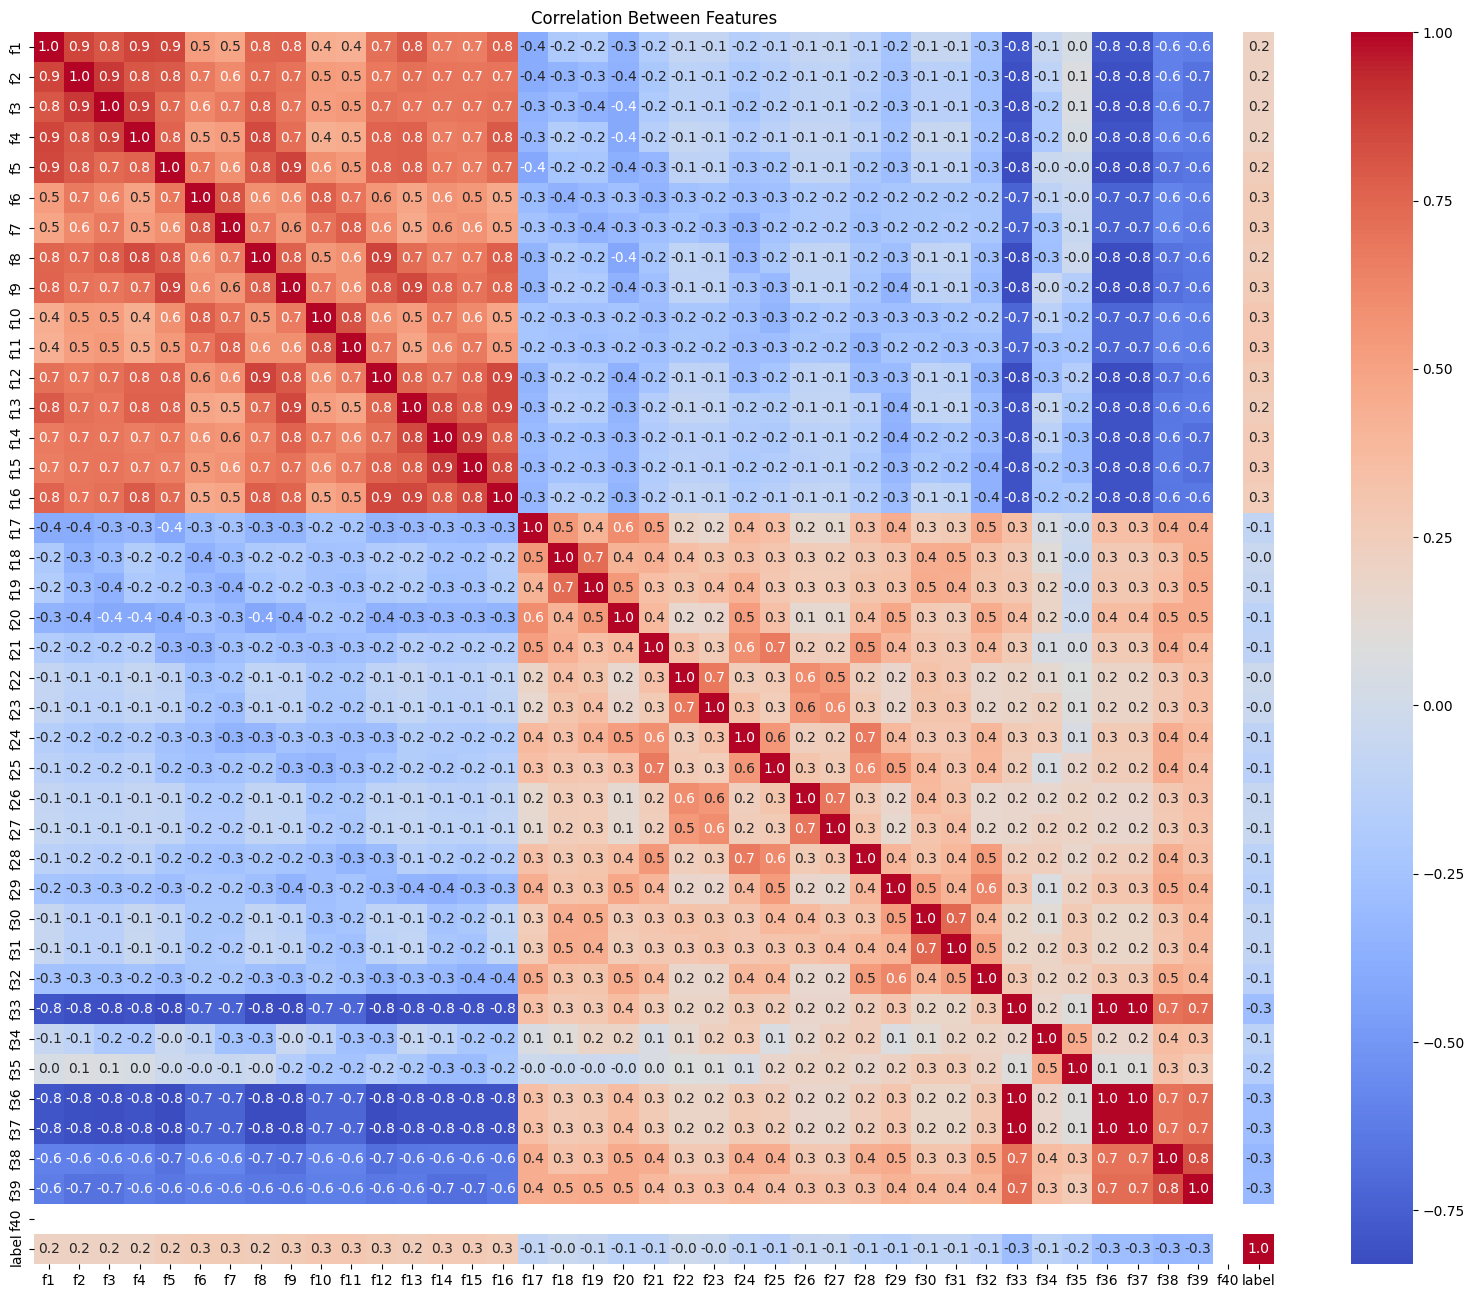

In [13]:
correlation = waste.corr()

# Visualization
plt.figure(figsize=(20,16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Between Features')
plt.show()

- Insight: 
1. Korelasi antar fitur f1 - f16 cenderung memiliki korelasi yang tinggi. Itu artinya, distribusi tinta atau area gelap pada setiap gambar memiliki hubungan atau pola tertentu. sehingga, distribusinya cukup mirip.
2. Ada Korelasi yang tinggi, yakni mencapai 1 pada fitur presentase pksel tinta terhadap piksel gambar, dengan sebaran tinta vertikal dan horizontal. Selain itu pda fitur sebaran tinta horizontal dan vertikal juga berkorelasi tinggi. Ini bisa menyebabkan duplikasi data yang membuat model menjadi menghitung 2x atau yang disebut redundan 


### 2.2 Univarate Analysis 

#### Target Distribution

<Axes: title={'center': 'Presentase Distribution of Target'}>

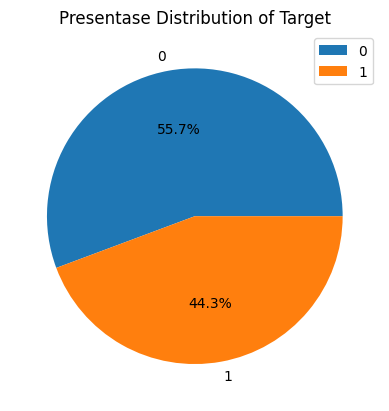

In [14]:
# Presentase penyebaran target
waste['label'].value_counts().plot.pie(autopct='%1.1f%%', title='Presentase Distribution of Target', legend=['Organik', 'Inorganic'])

In [15]:
selisih = 55.7 - 44.3
print(f'Selisih: {selisih}%')

data = (waste.shape[0] * selisih) / 100
print(data)

Selisih: 11.400000000000006%
2572.296000000001


- Insight:
1. Sampah Organik dan Inorganic memiliki jumlah yang cukup sama pada dataset ini. Dimana, sampah organik mendominasi dari sampah inorganik. Selisih antara kedua target tidak terlalu ekstrim, dengan selisih sekitar 11.40%
2. Target cukup balance.

#### Boxplot Analysis

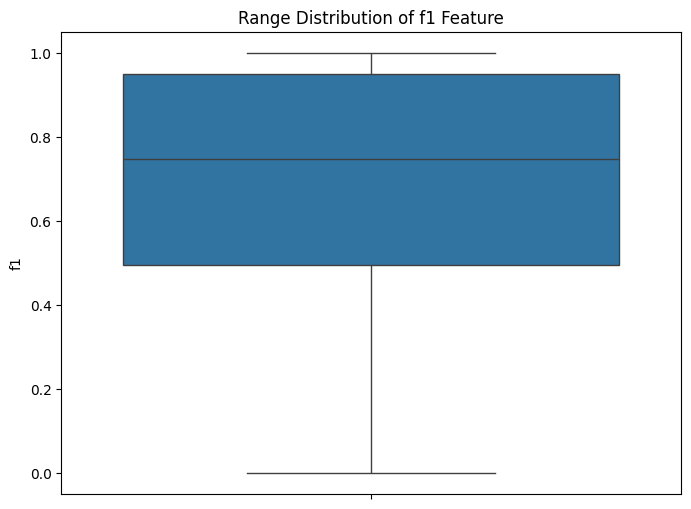

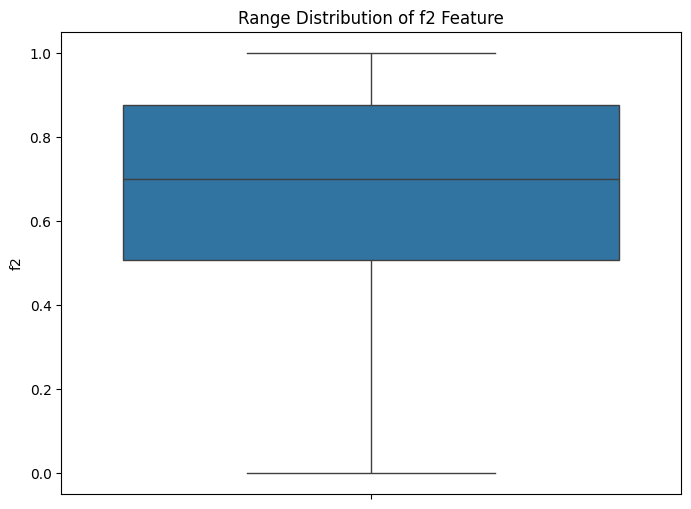

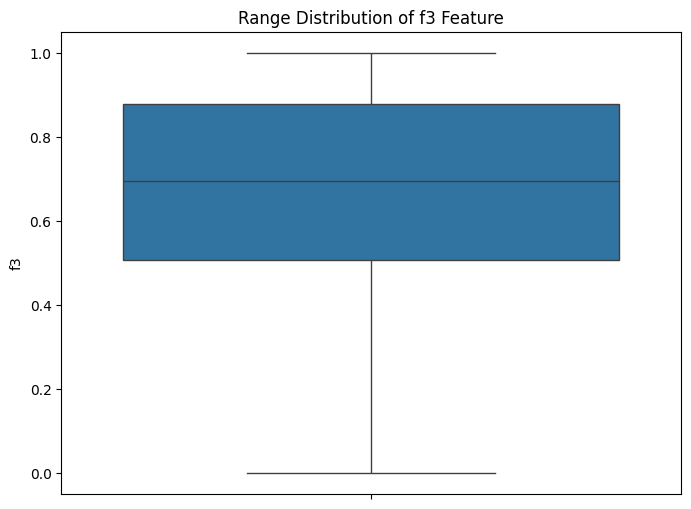

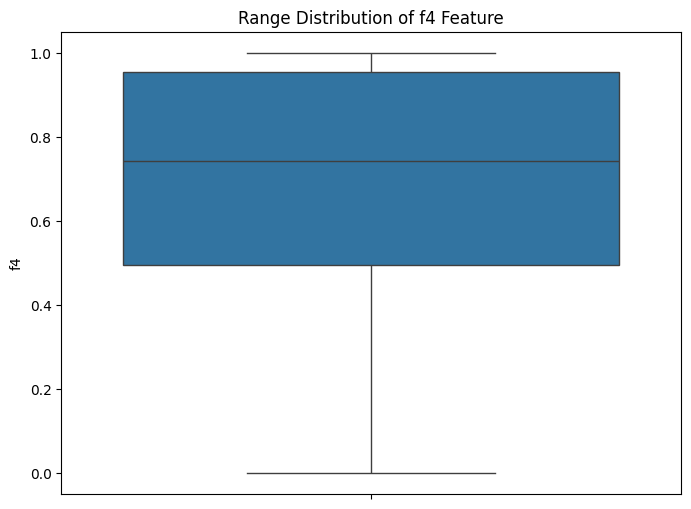

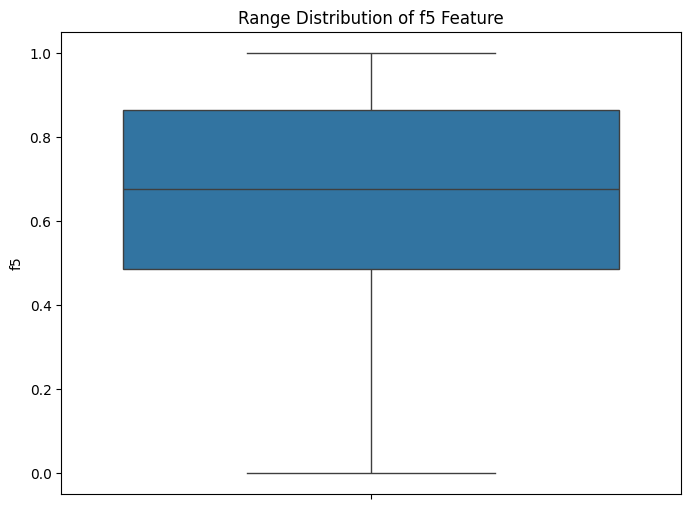

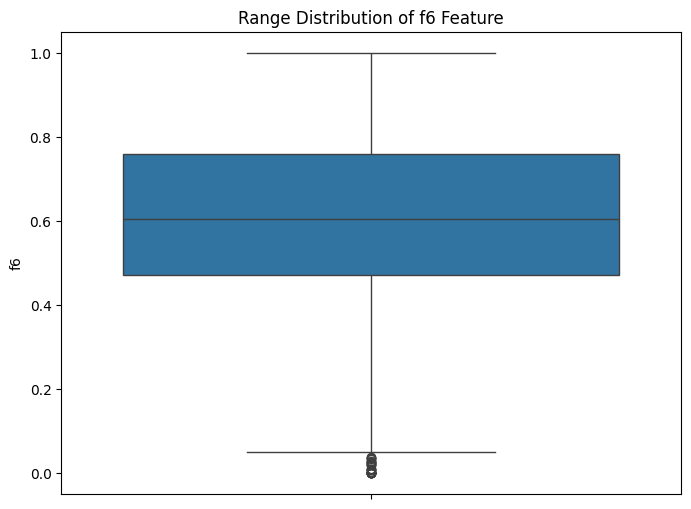

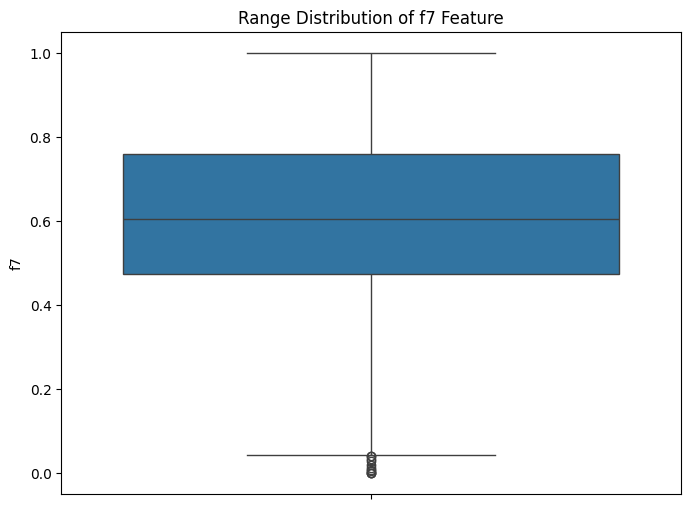

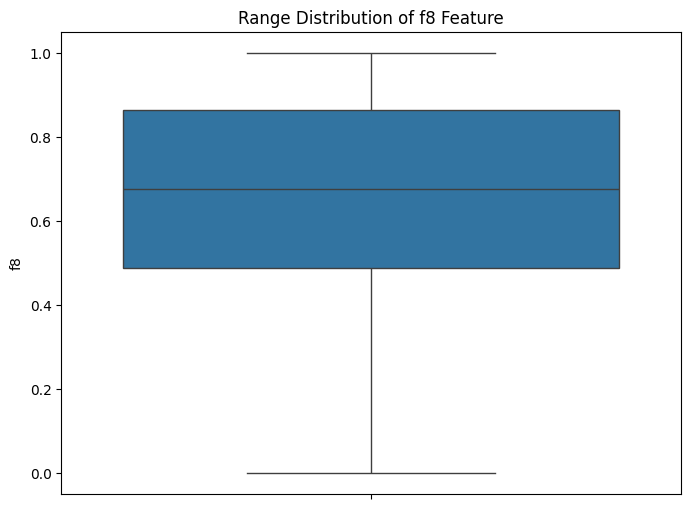

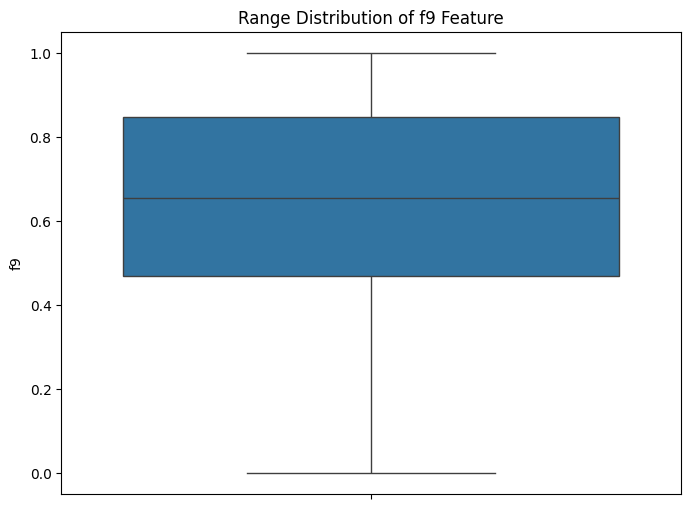

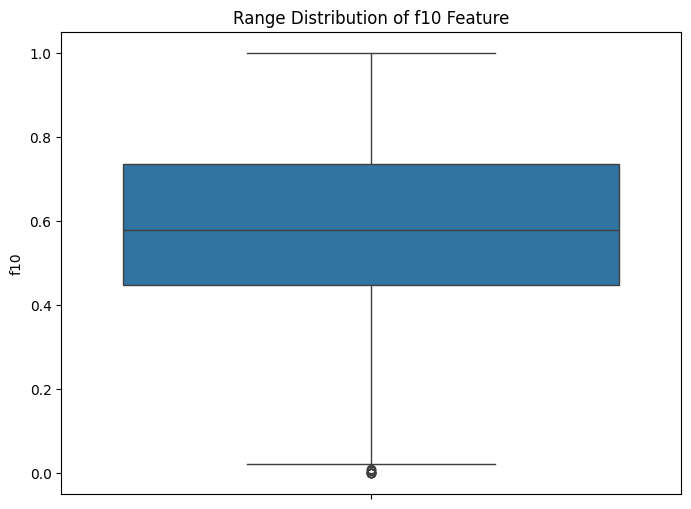

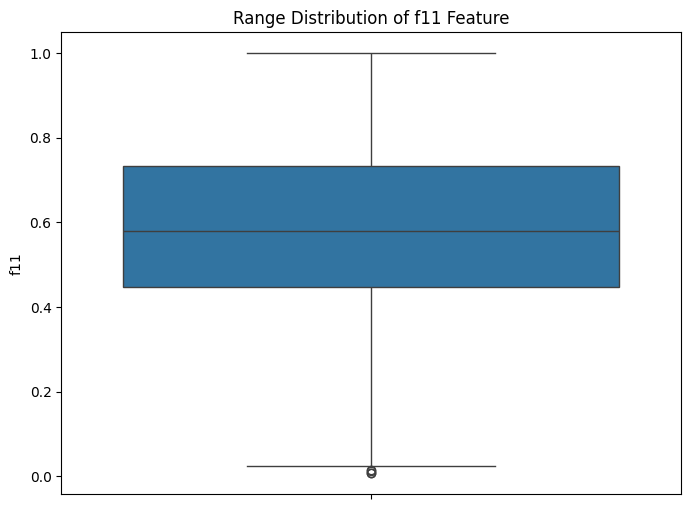

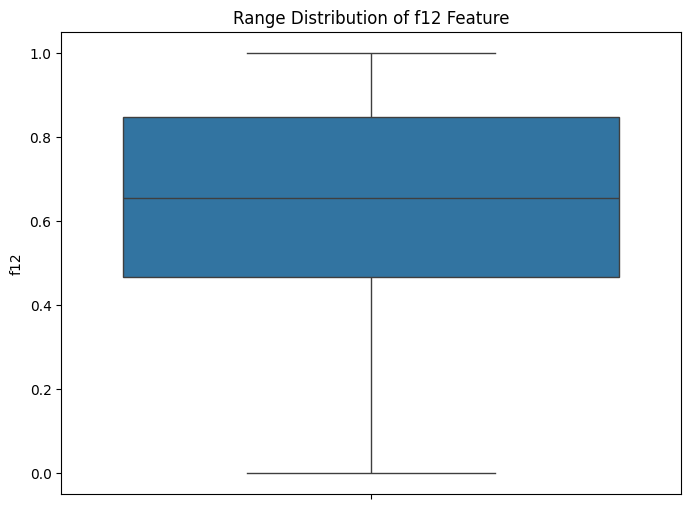

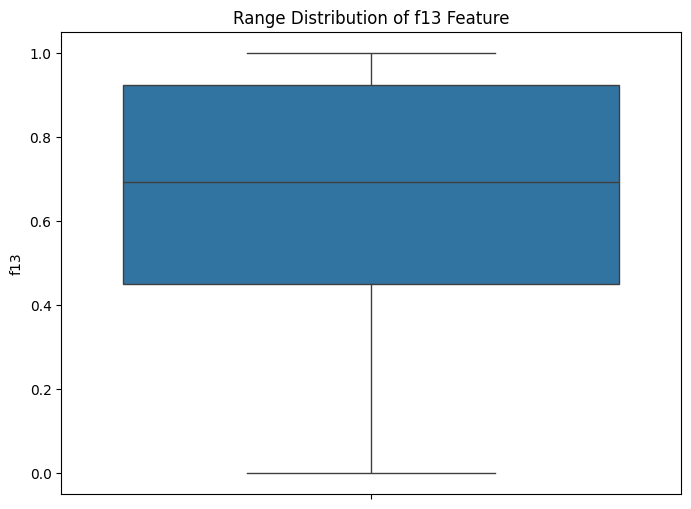

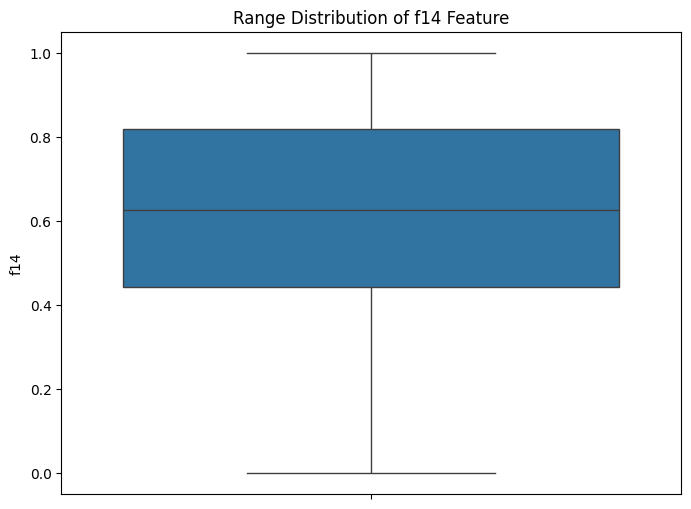

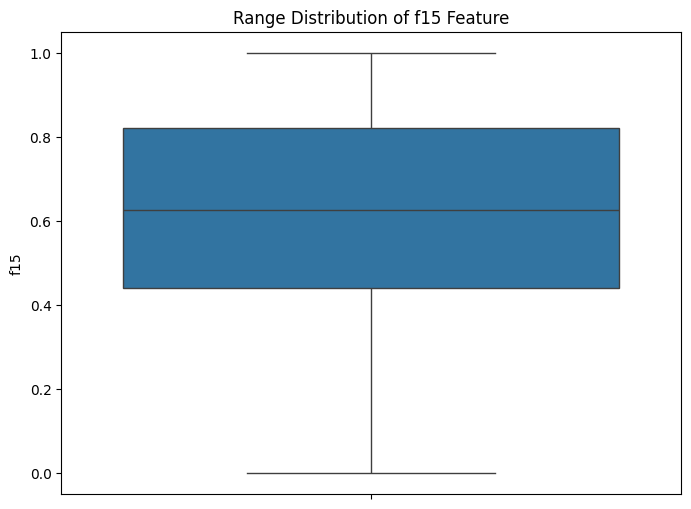

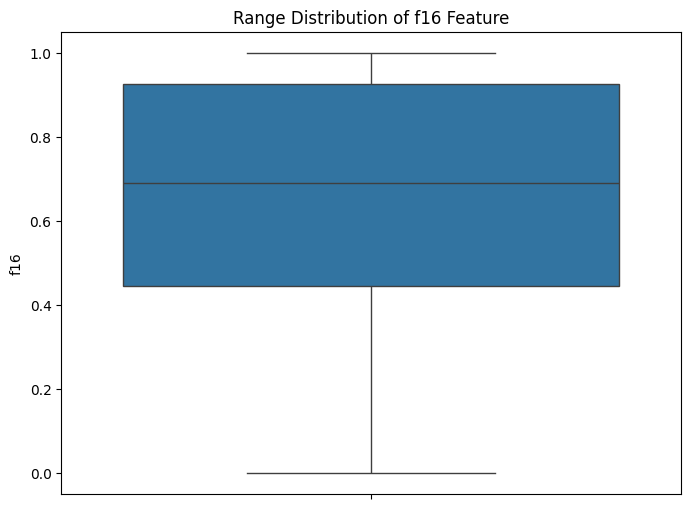

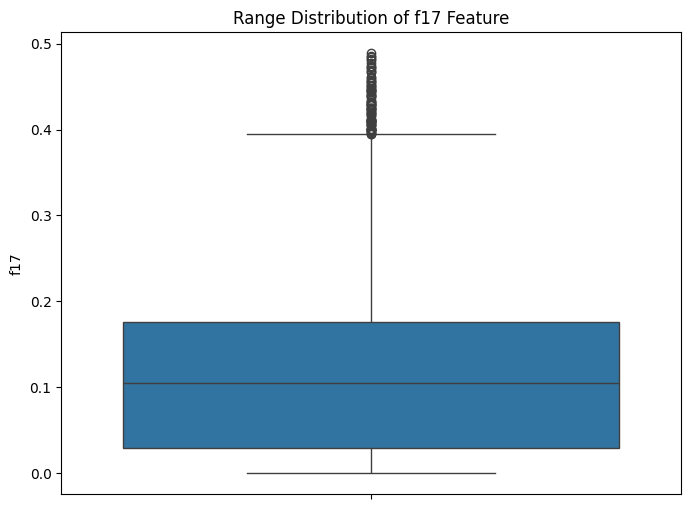

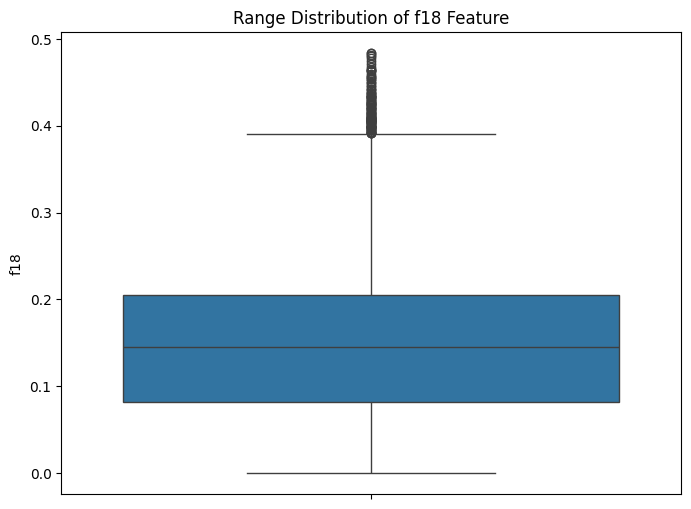

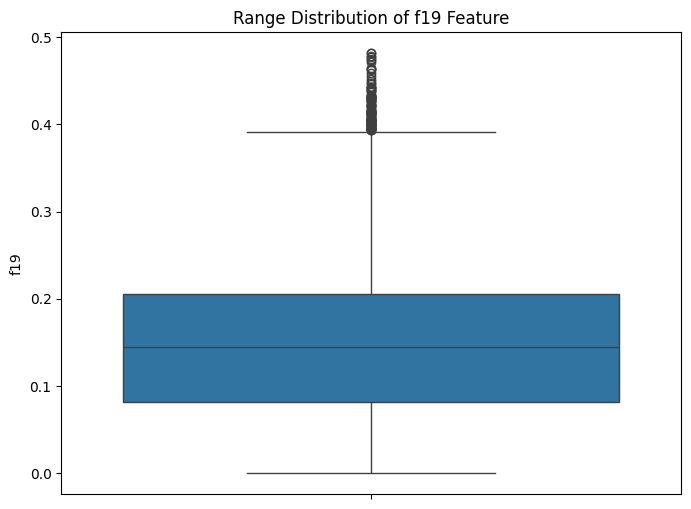

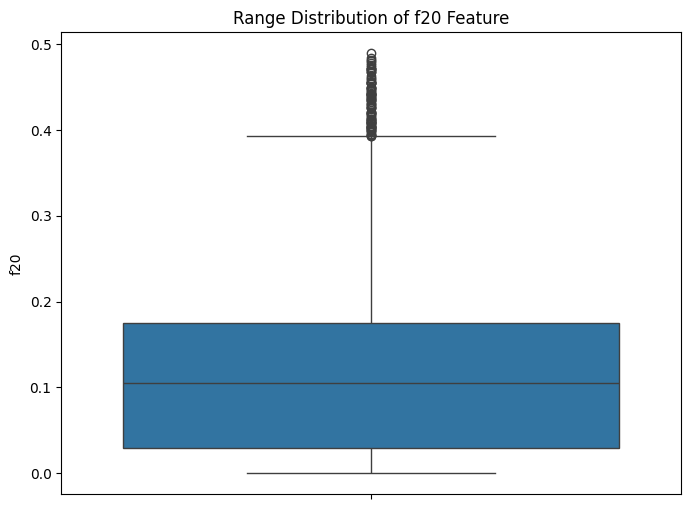

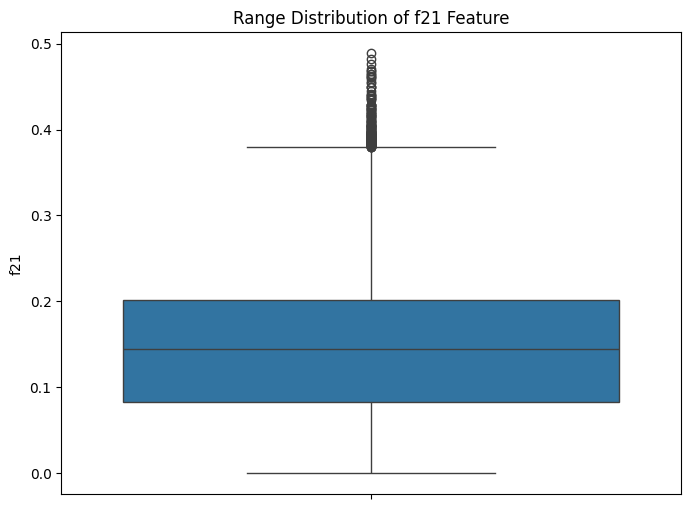

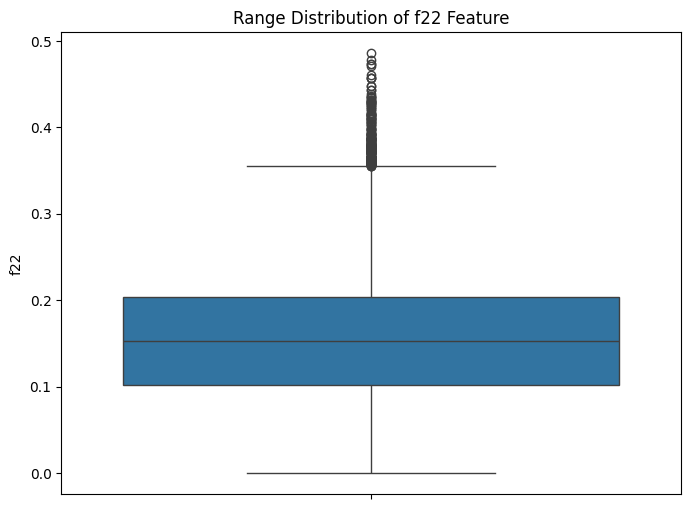

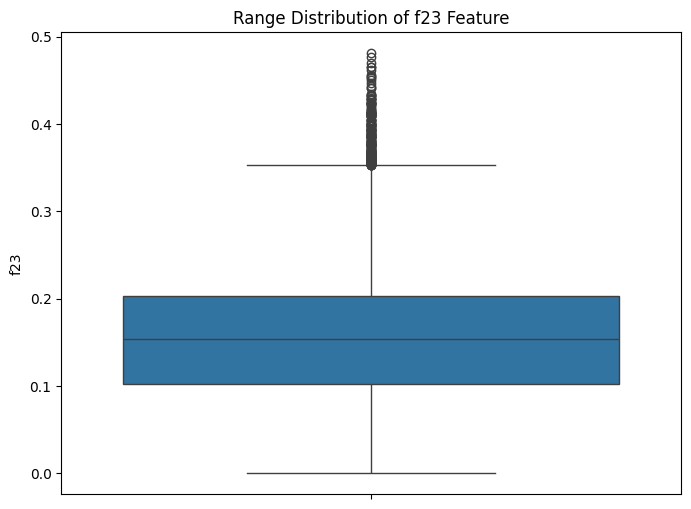

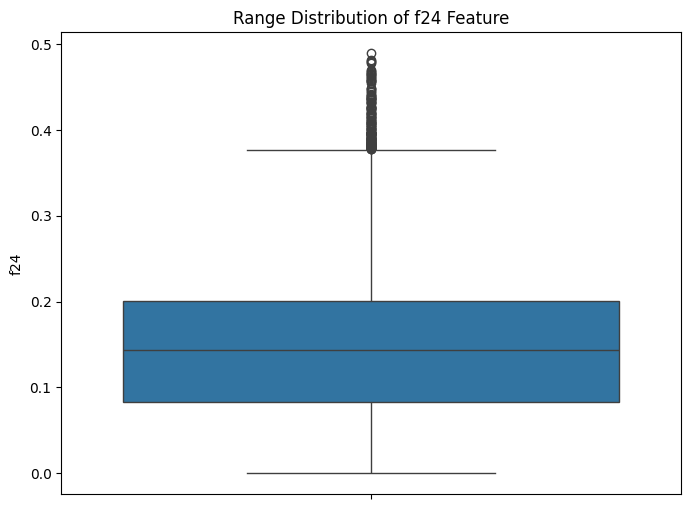

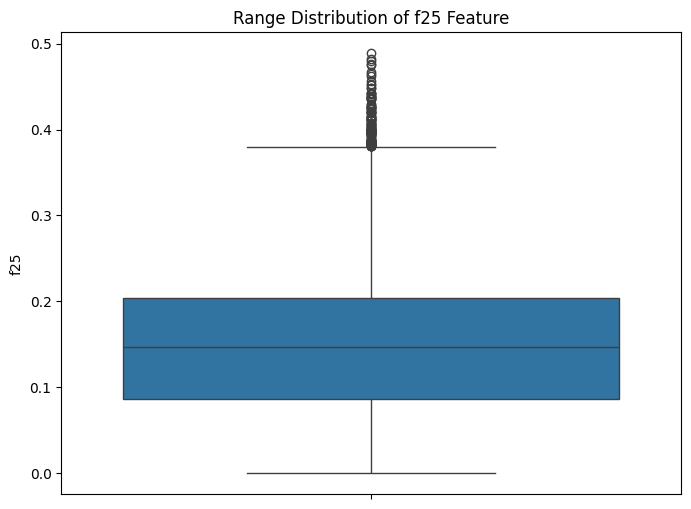

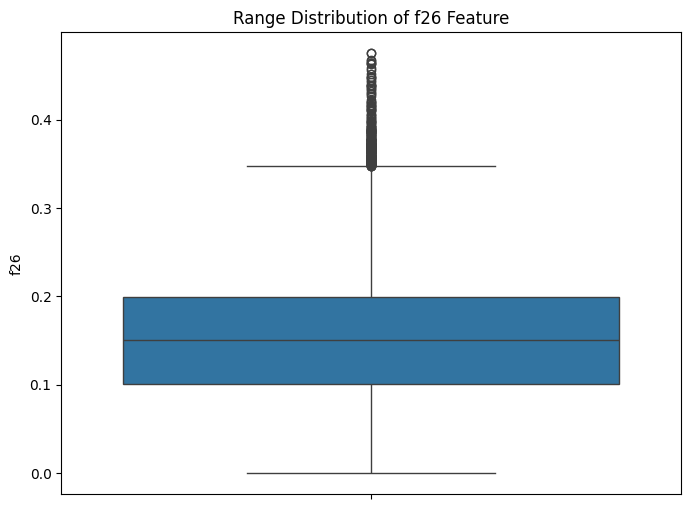

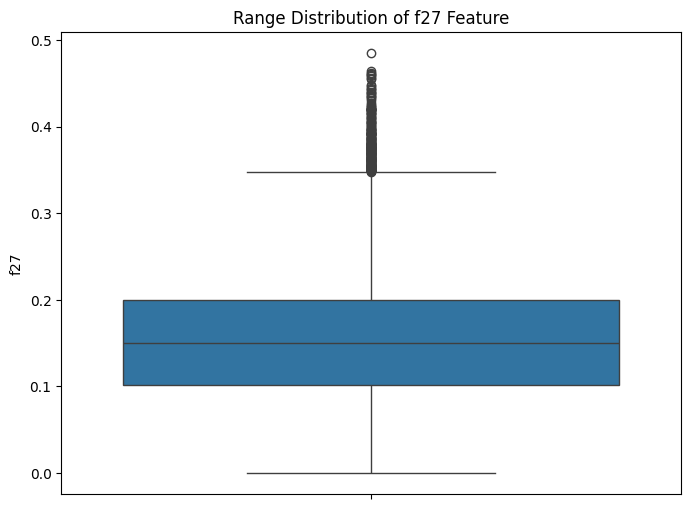

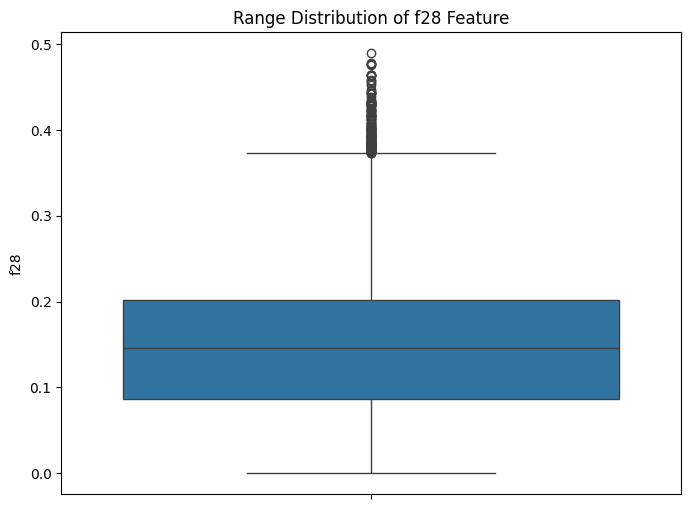

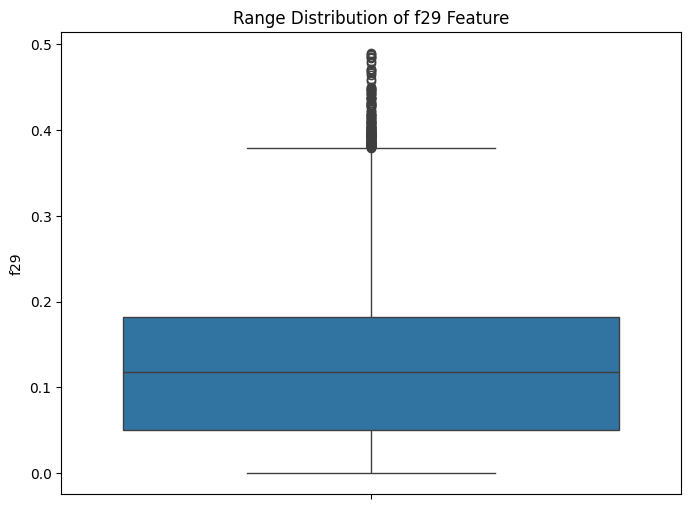

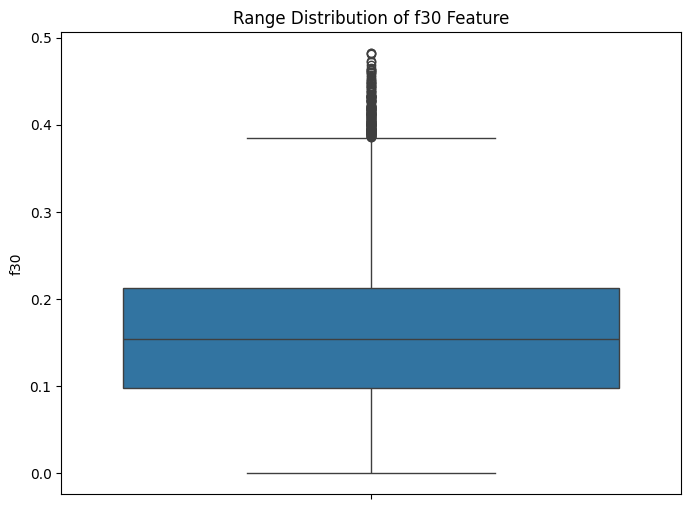

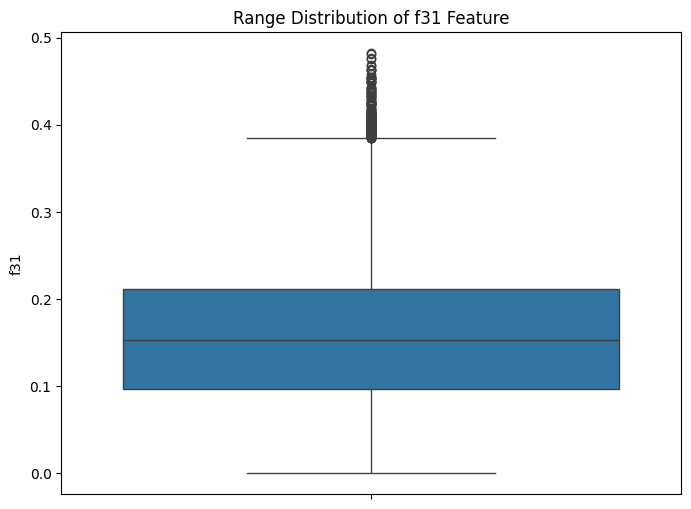

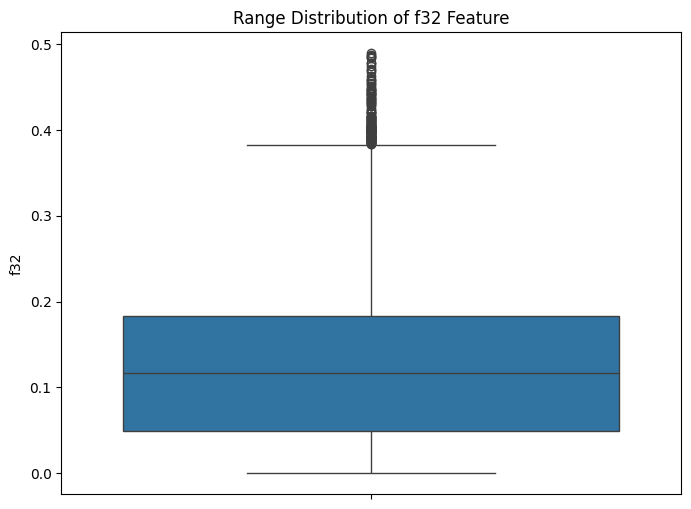

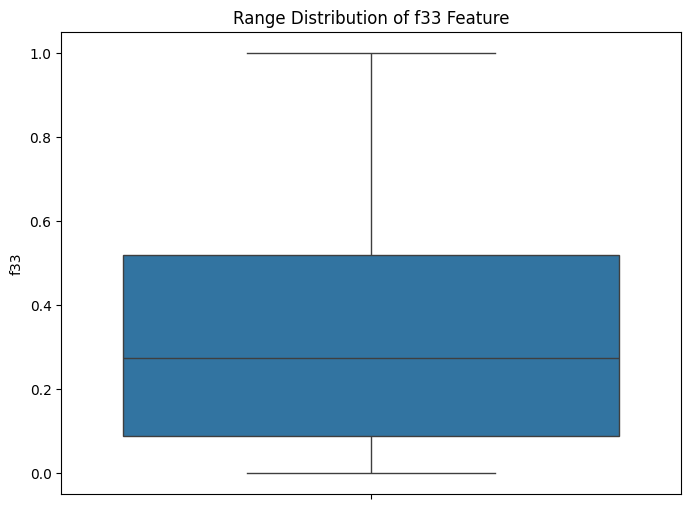

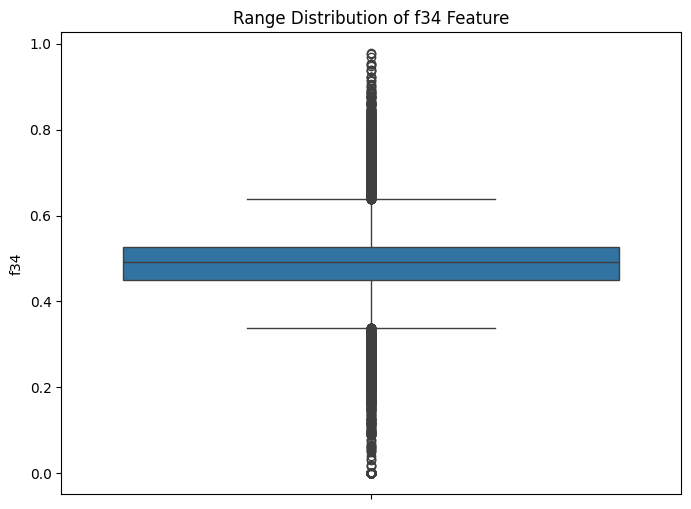

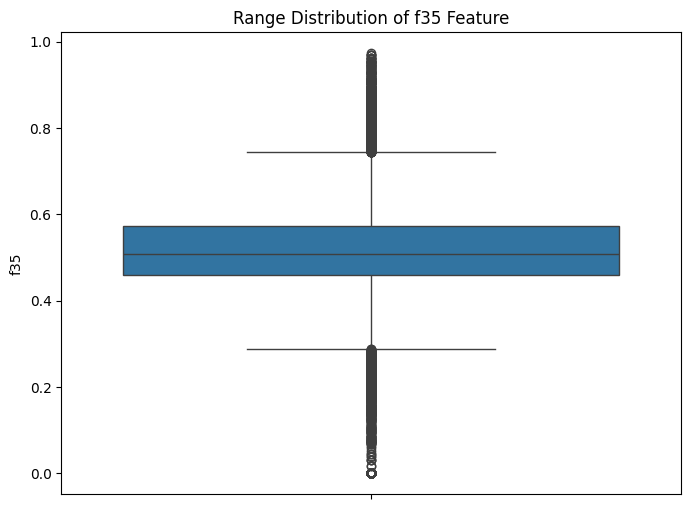

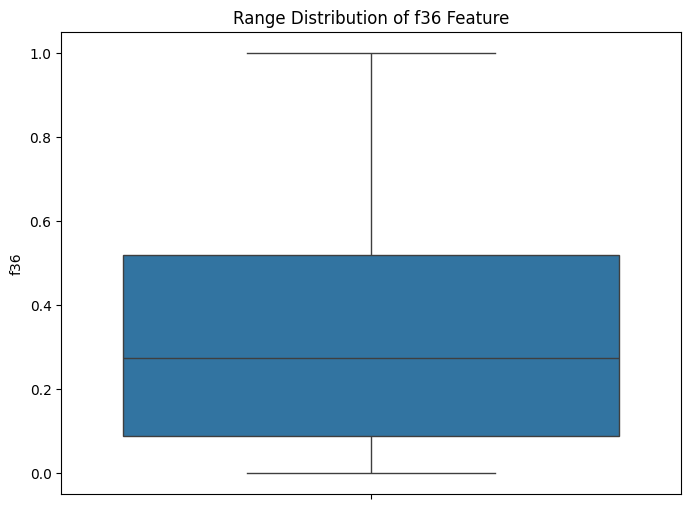

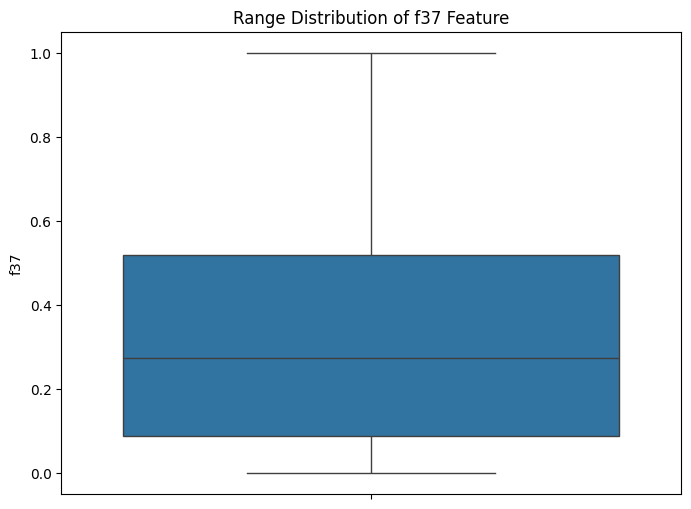

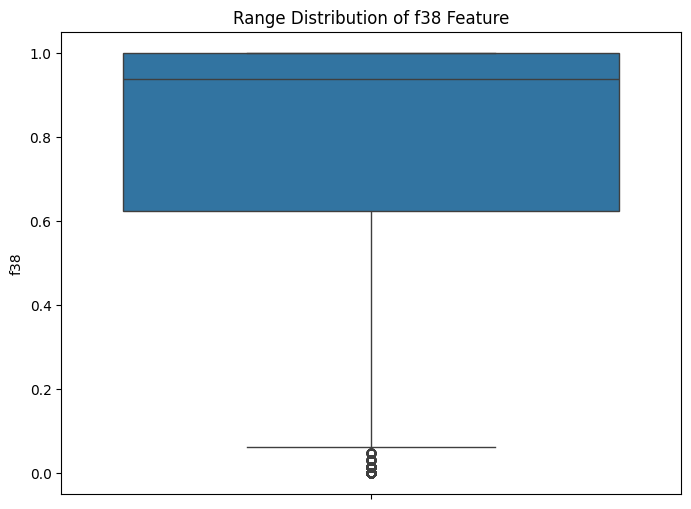

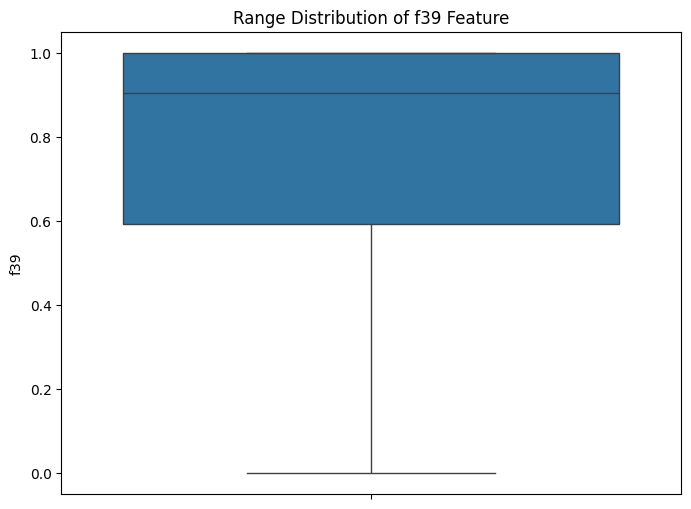

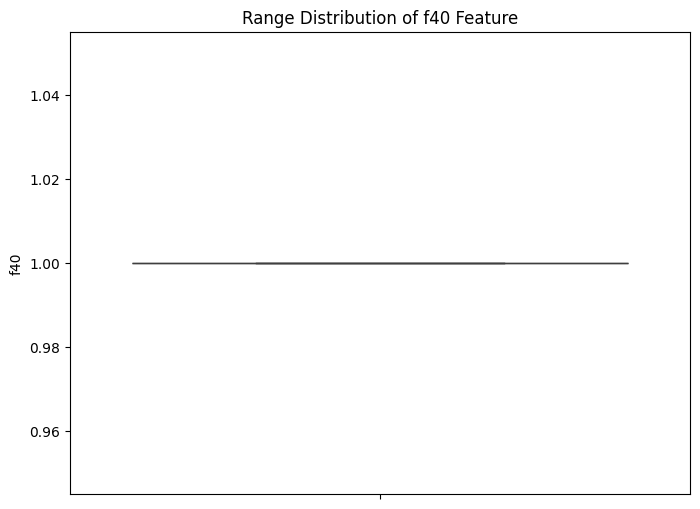

In [16]:
# Show range distribution per featrue 
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(num_cols[col])
    plt.title(f'Range Distribution of {col} Feature')
    plt.show()

### 2.3 Bivariate Analysis

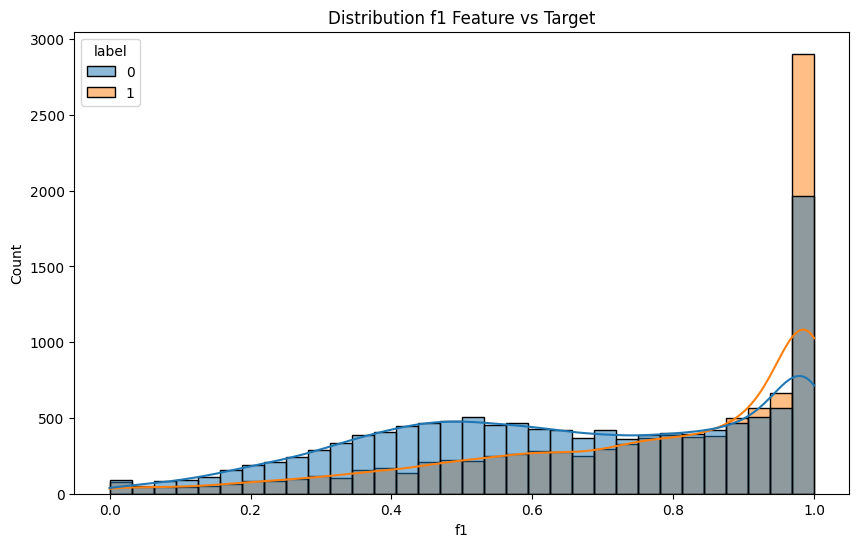

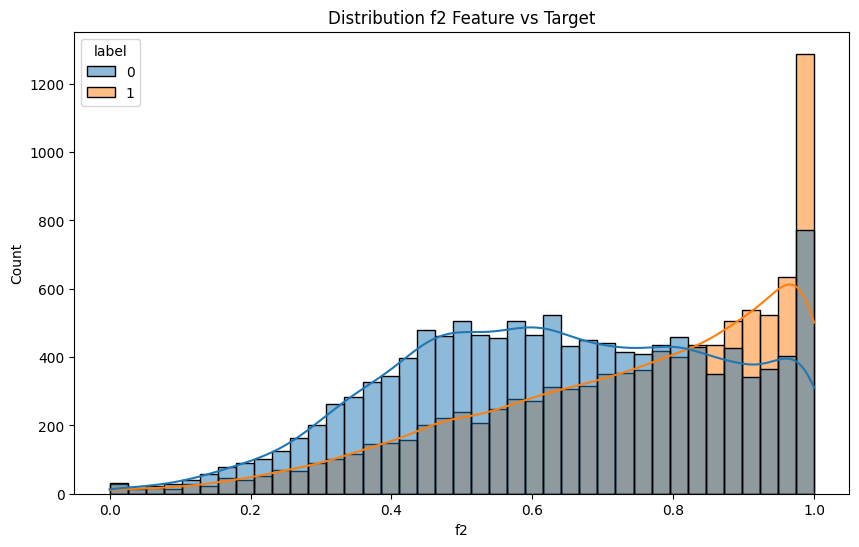

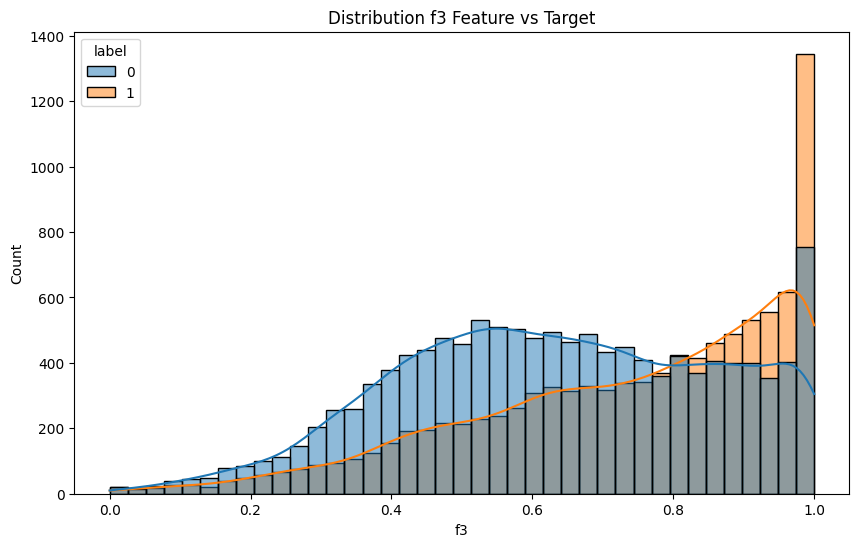

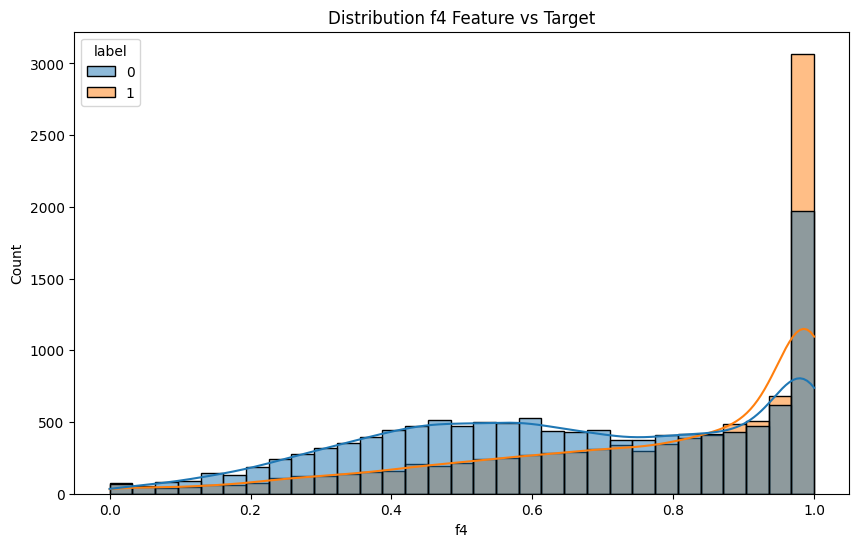

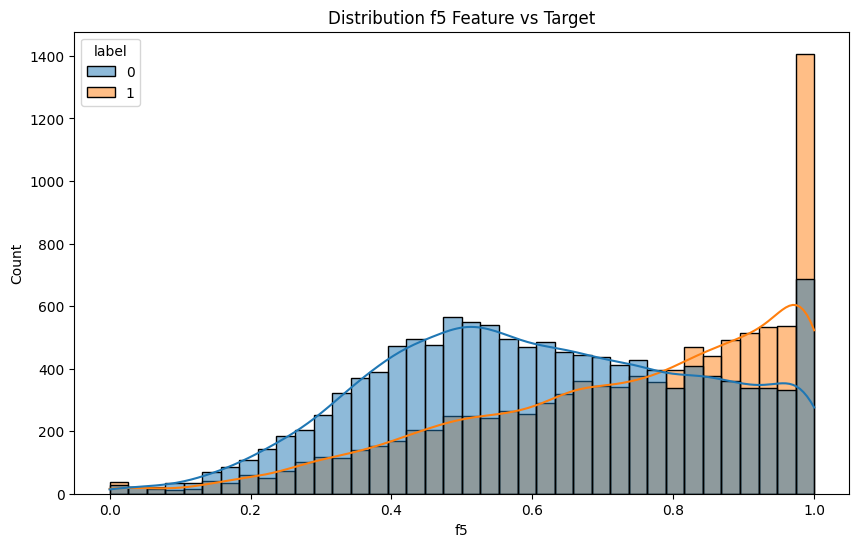

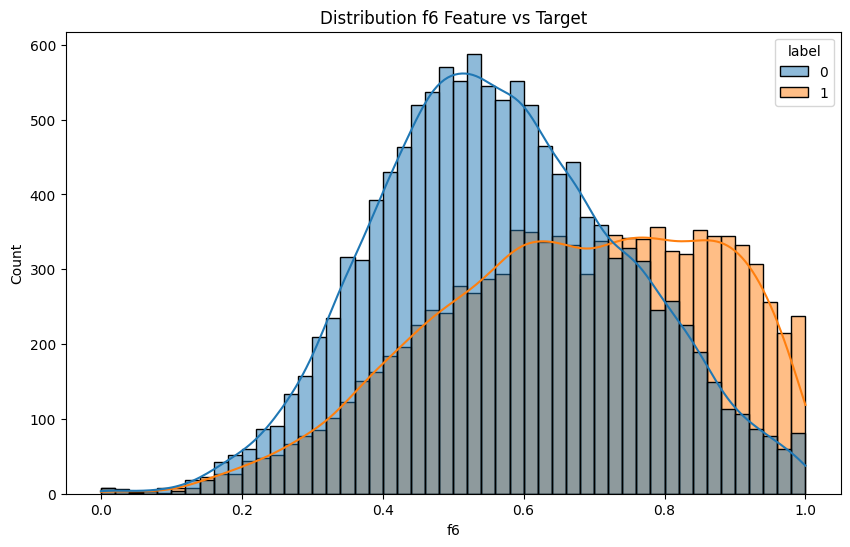

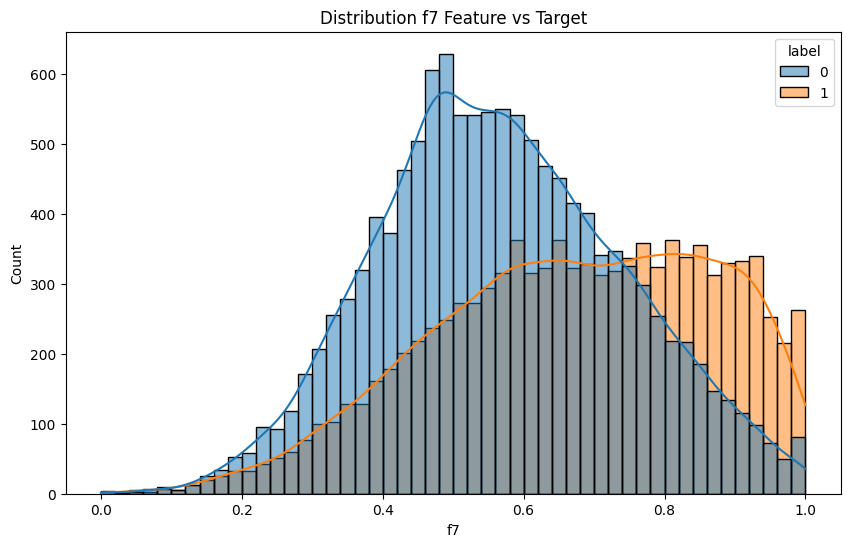

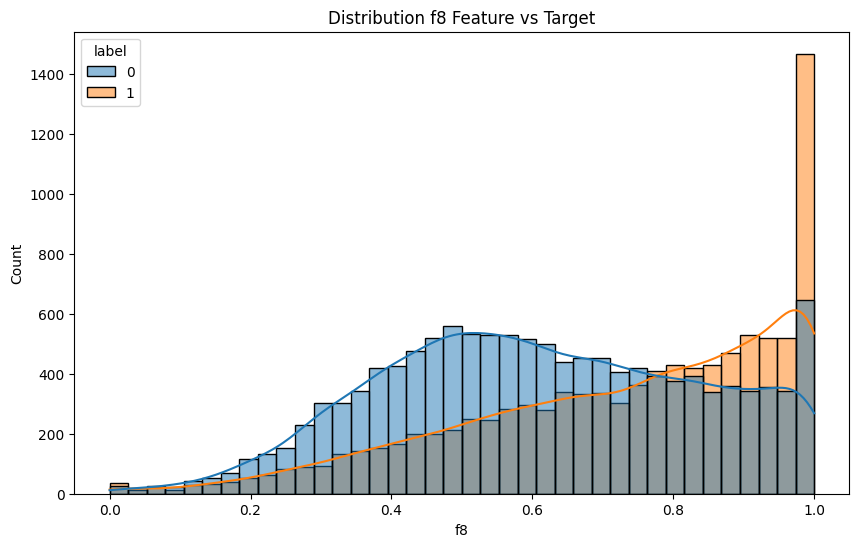

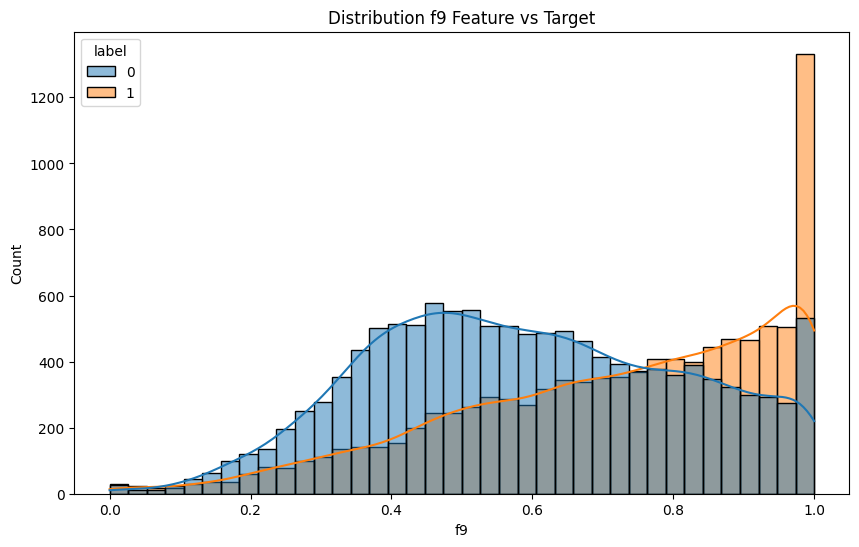

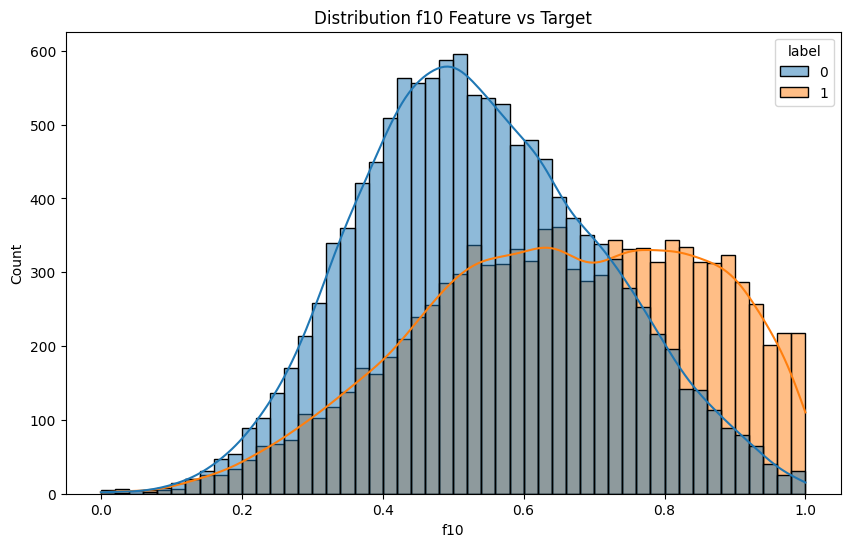

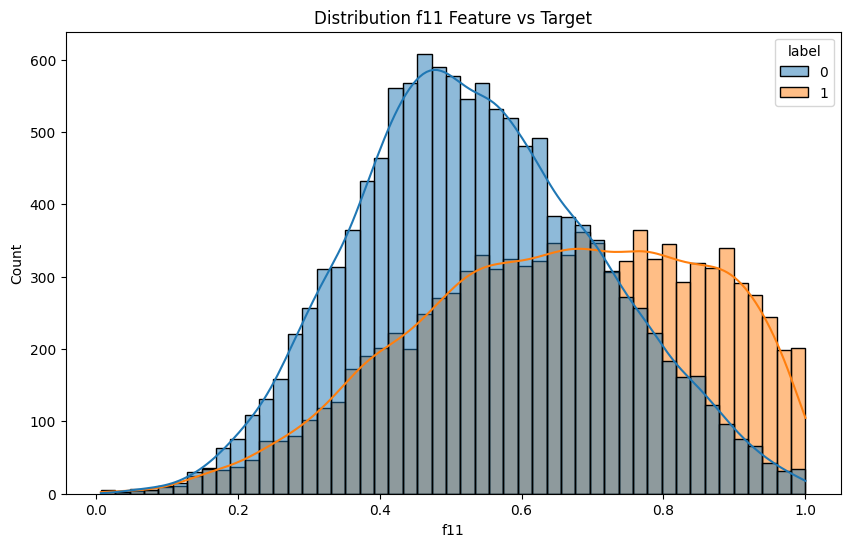

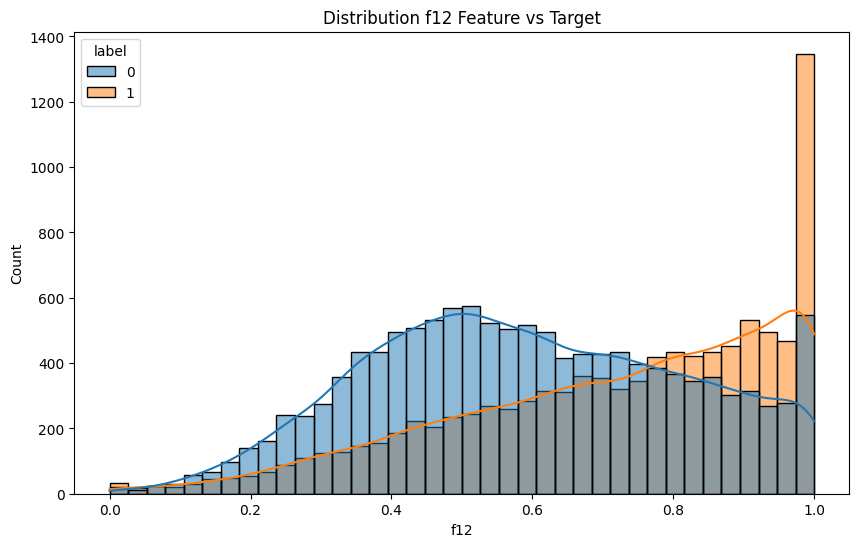

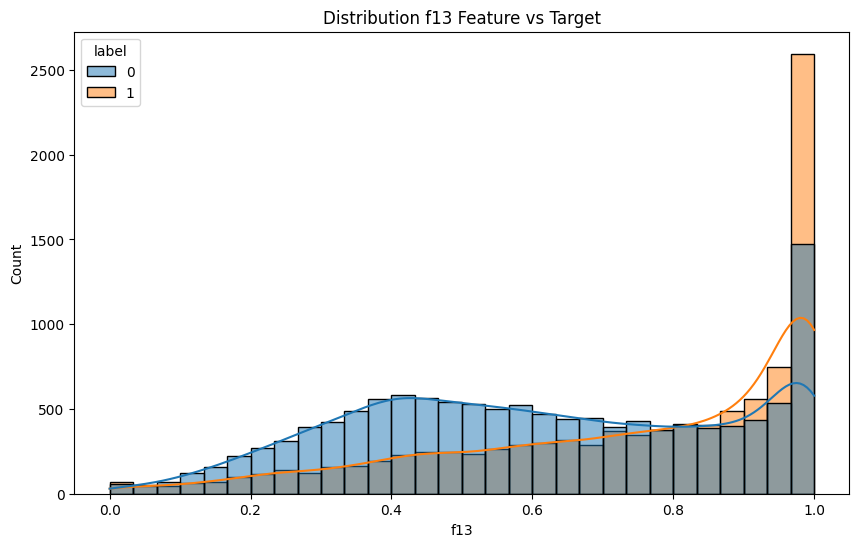

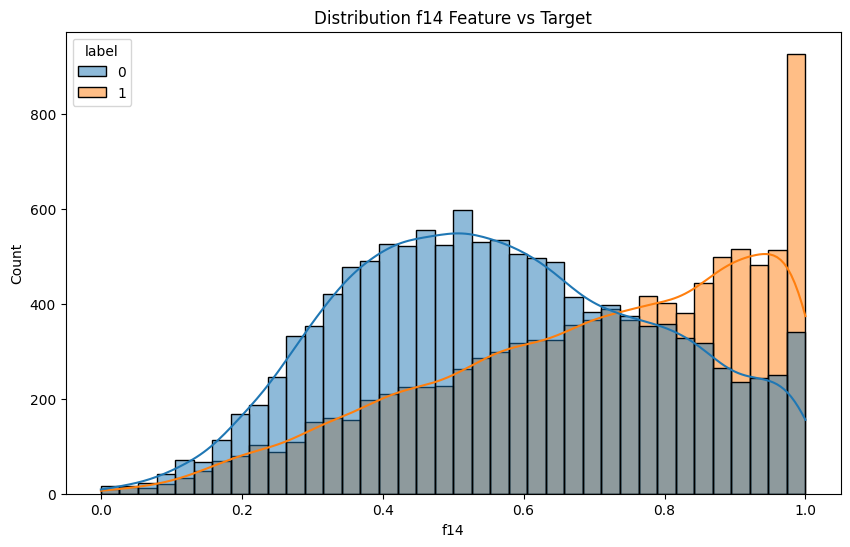

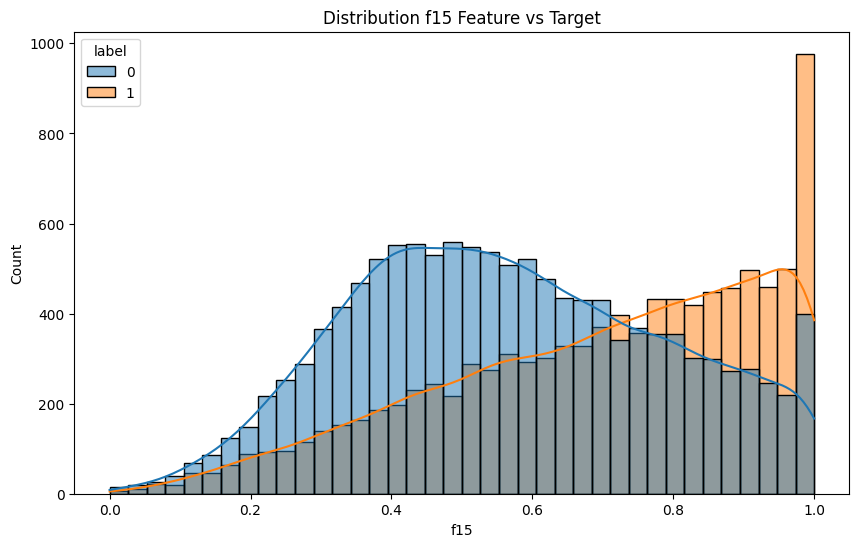

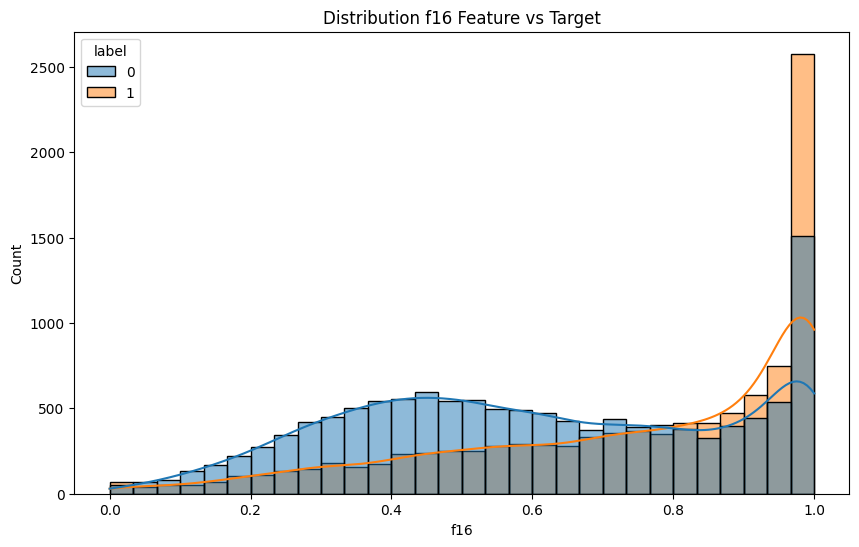

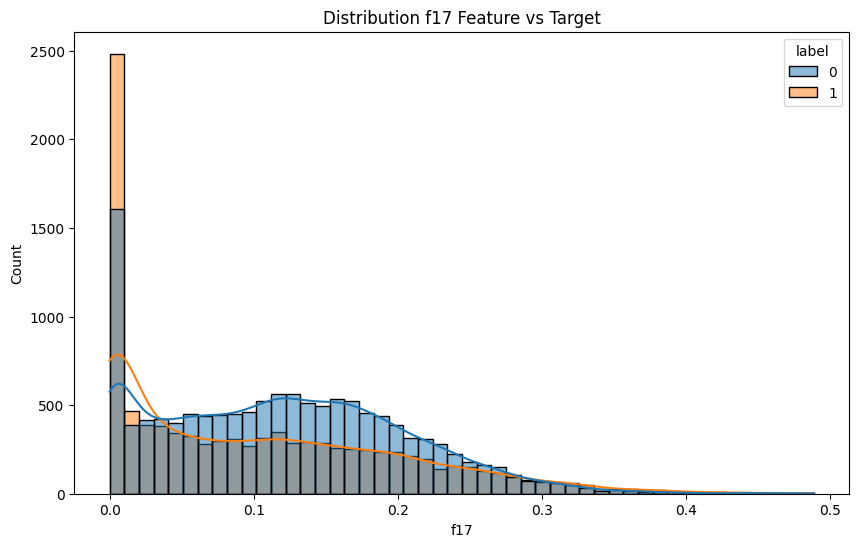

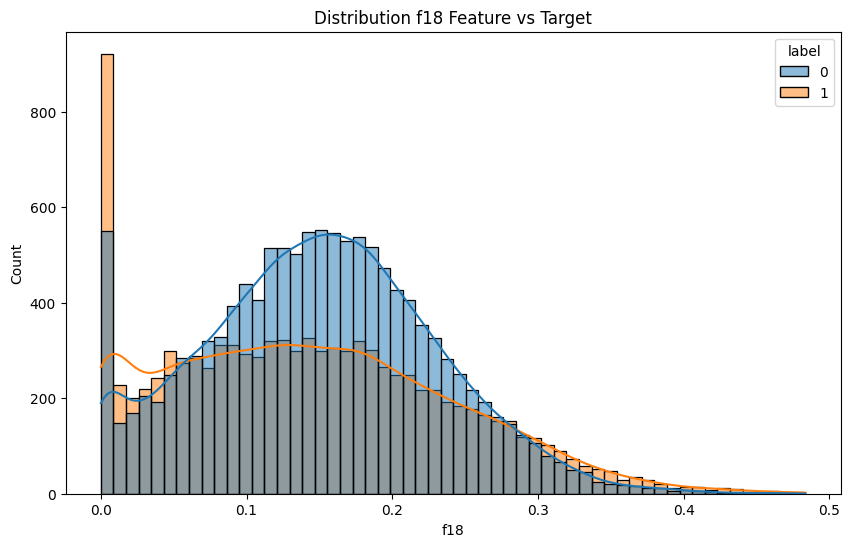

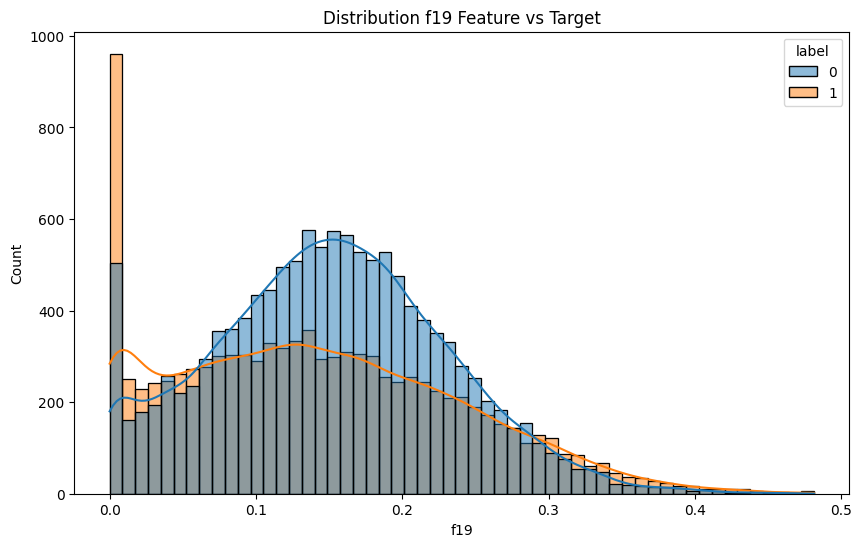

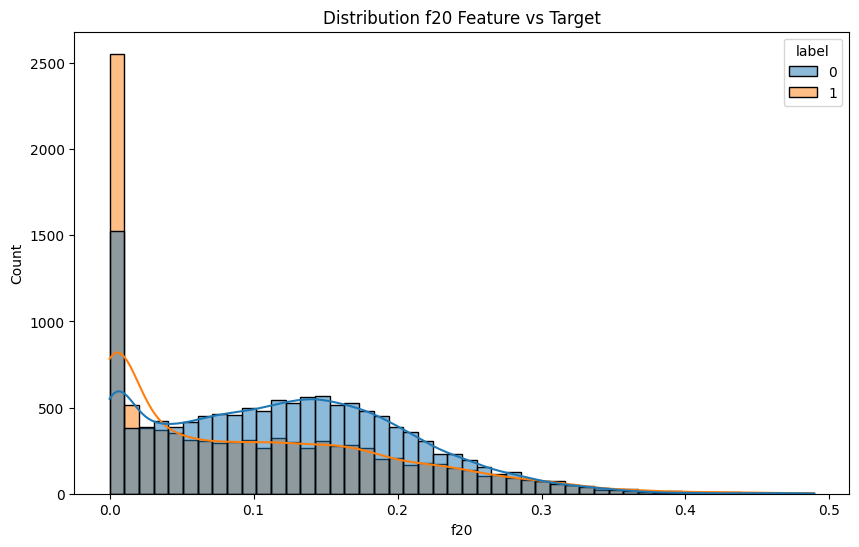

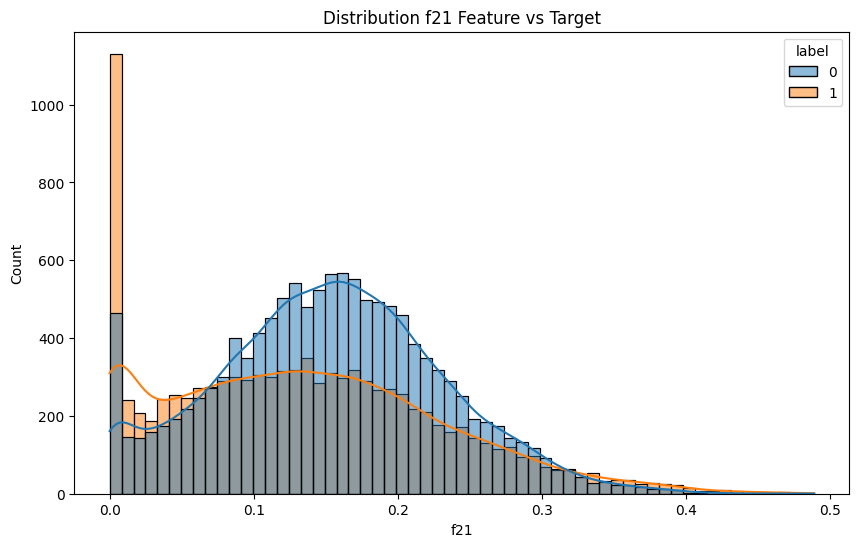

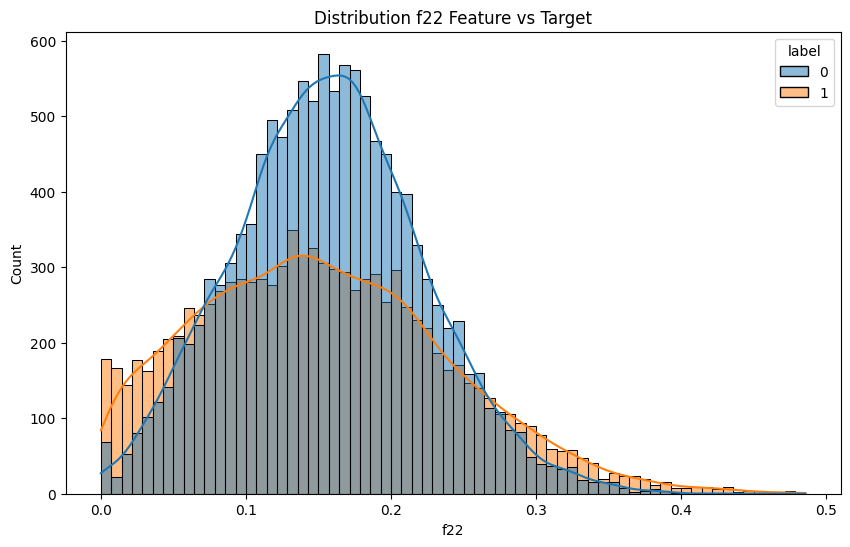

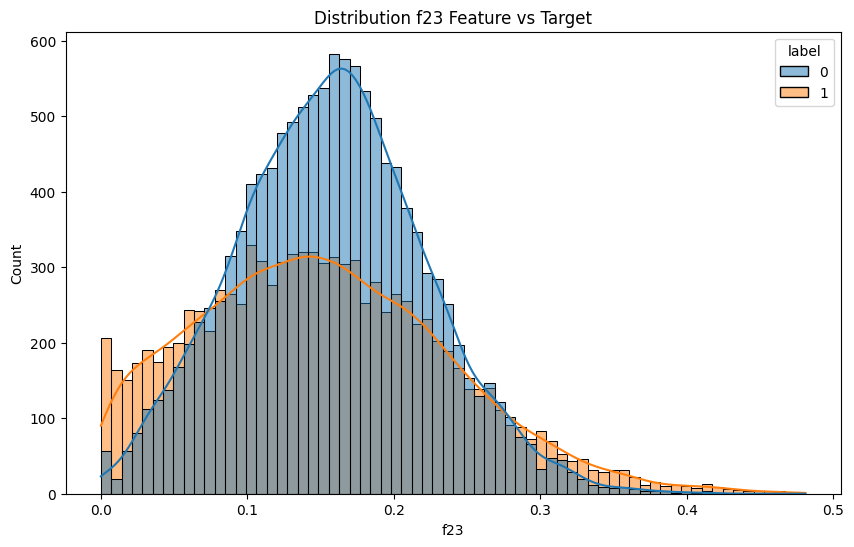

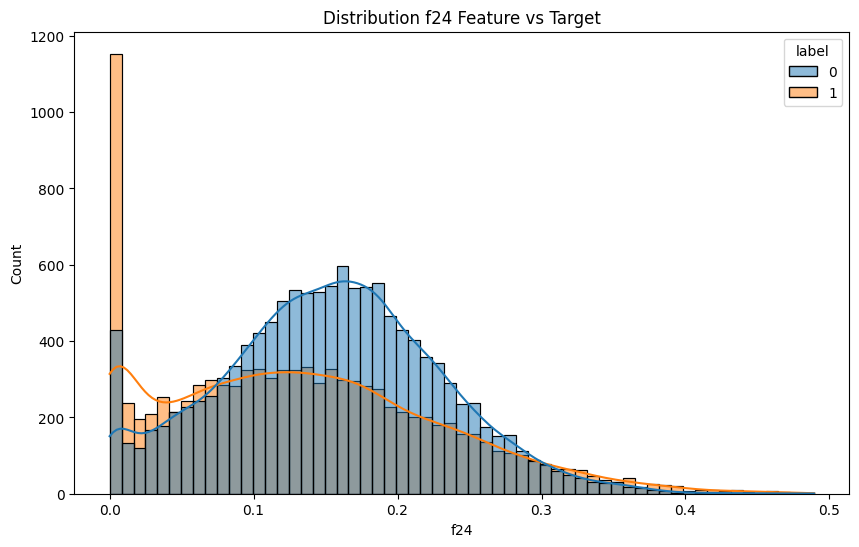

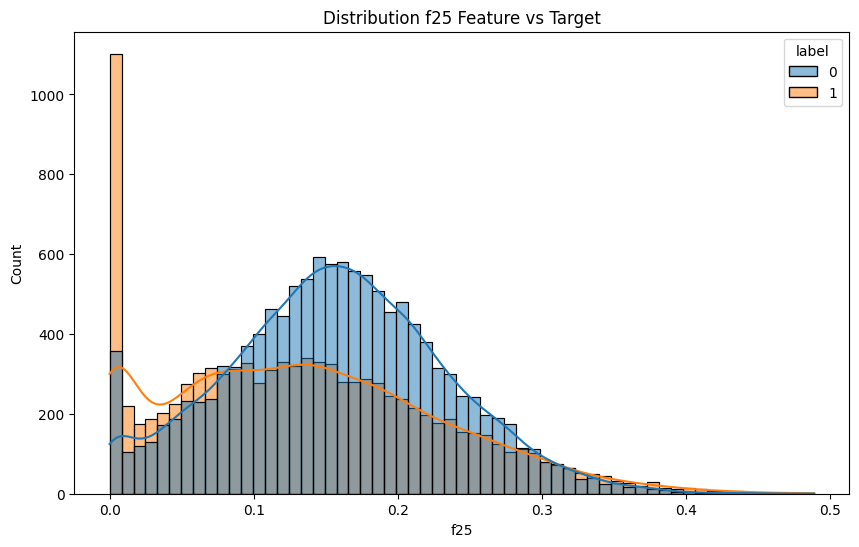

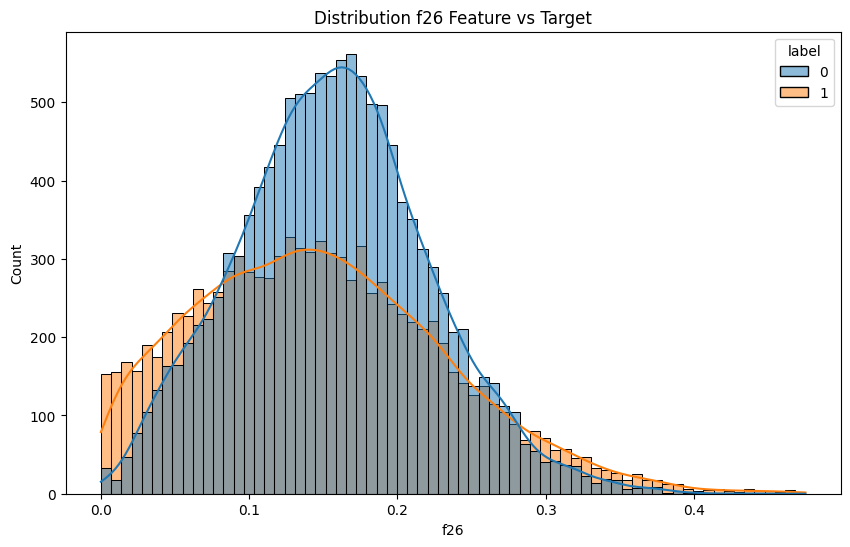

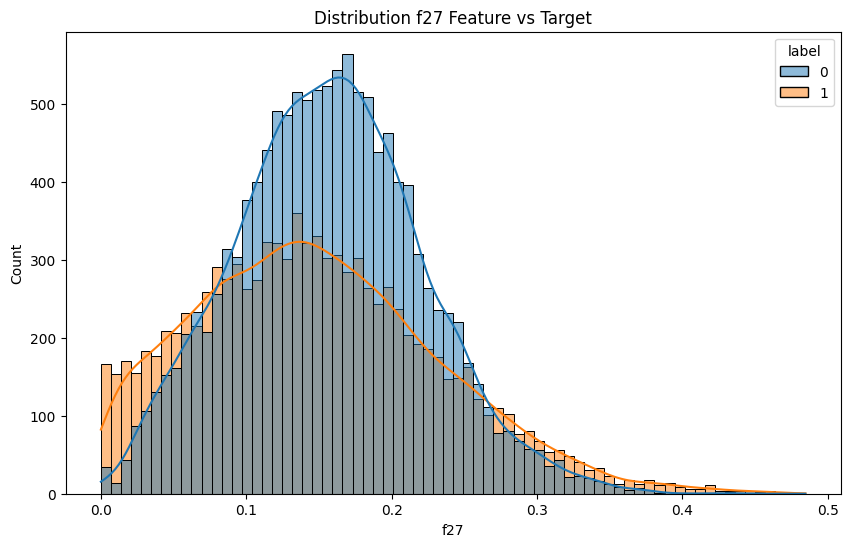

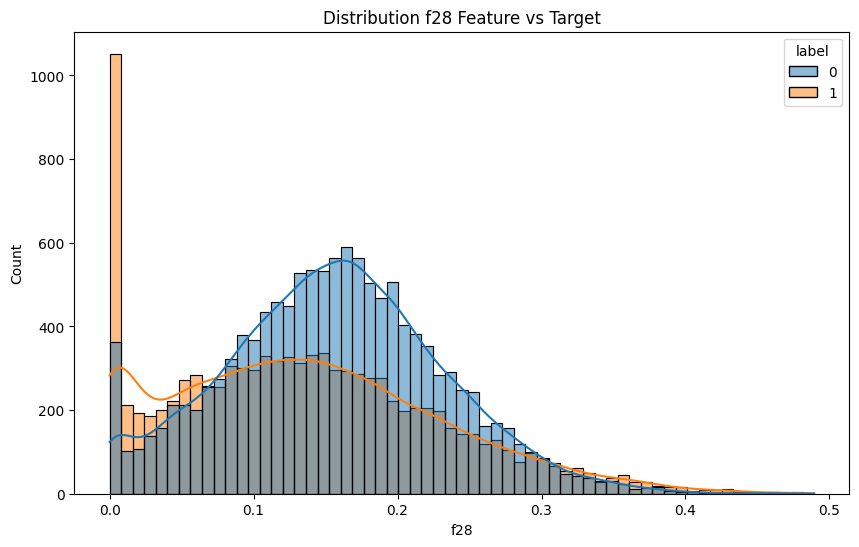

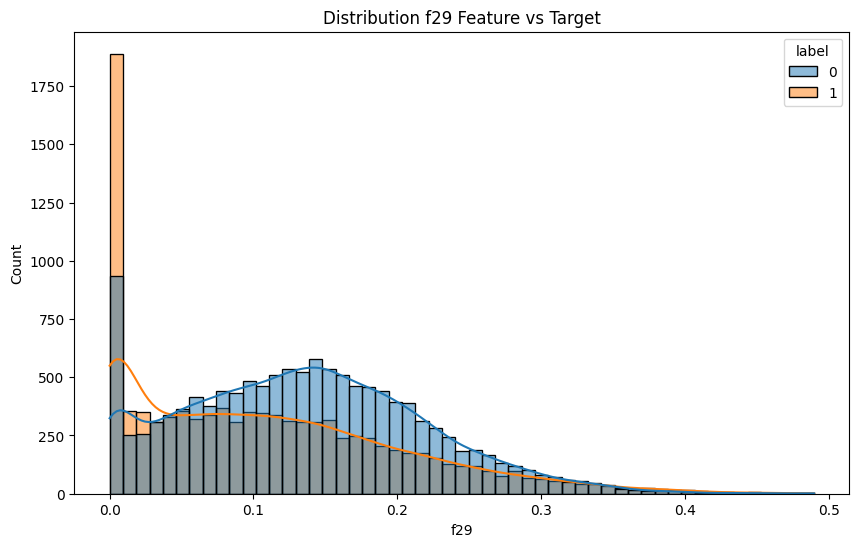

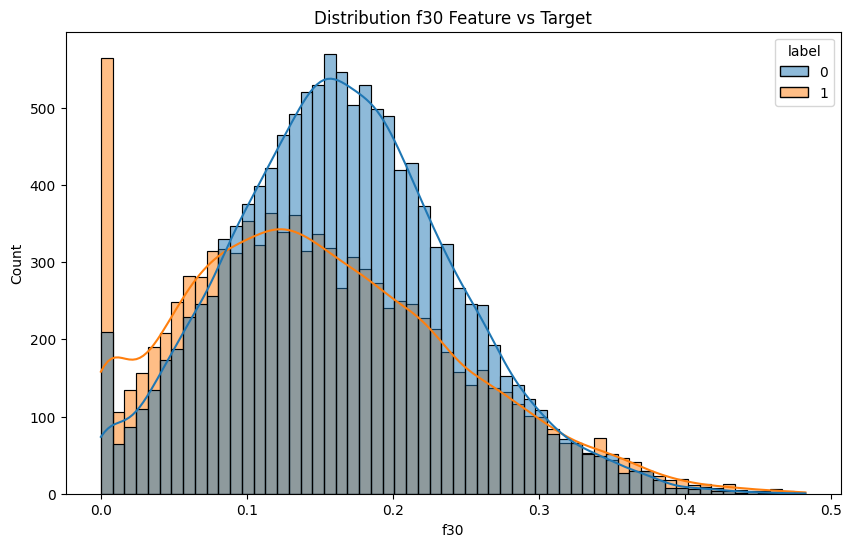

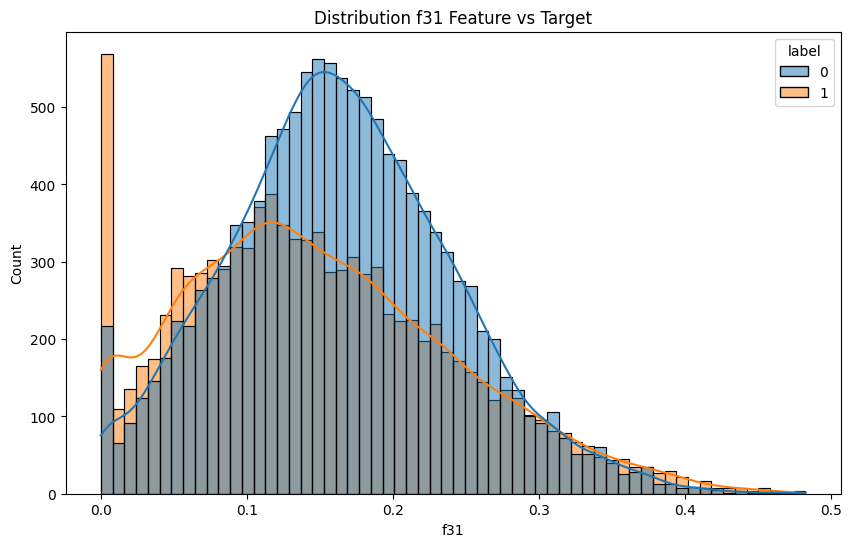

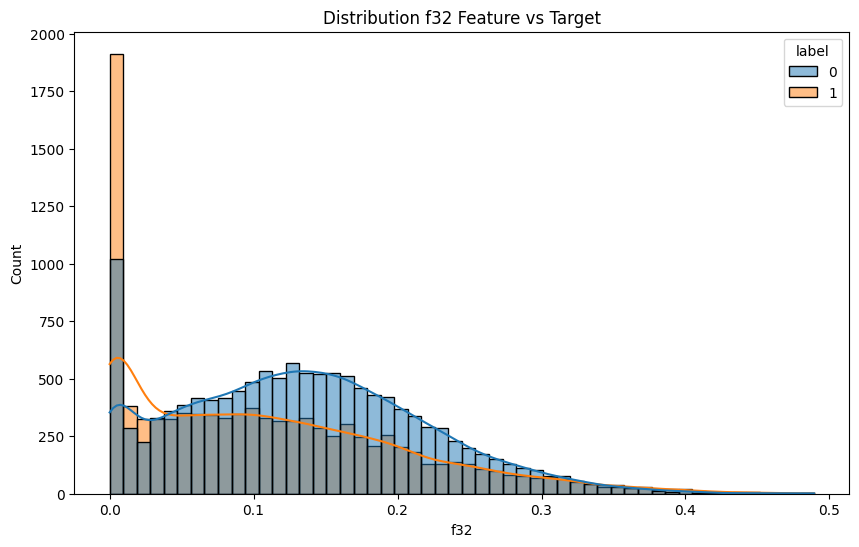

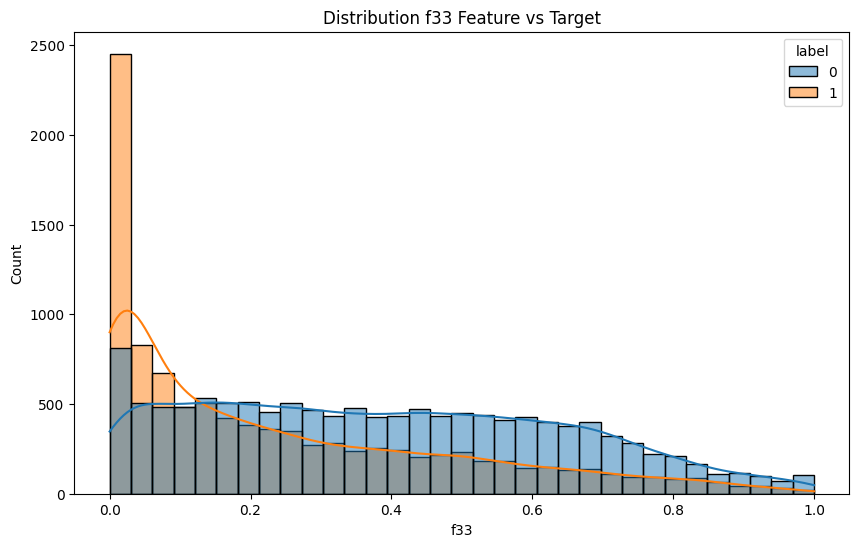

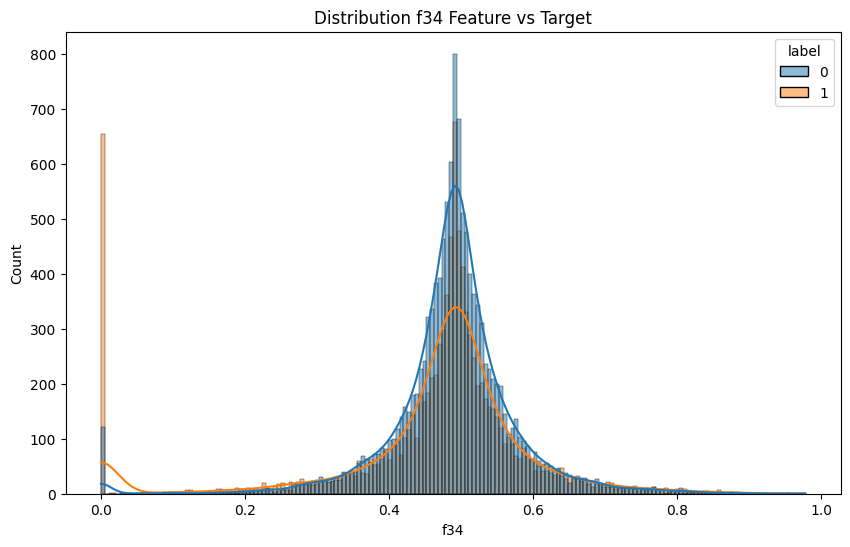

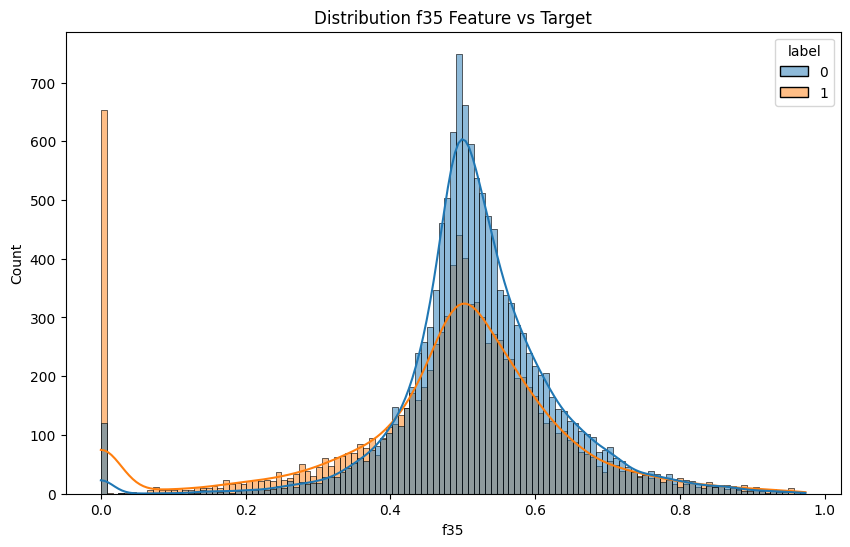

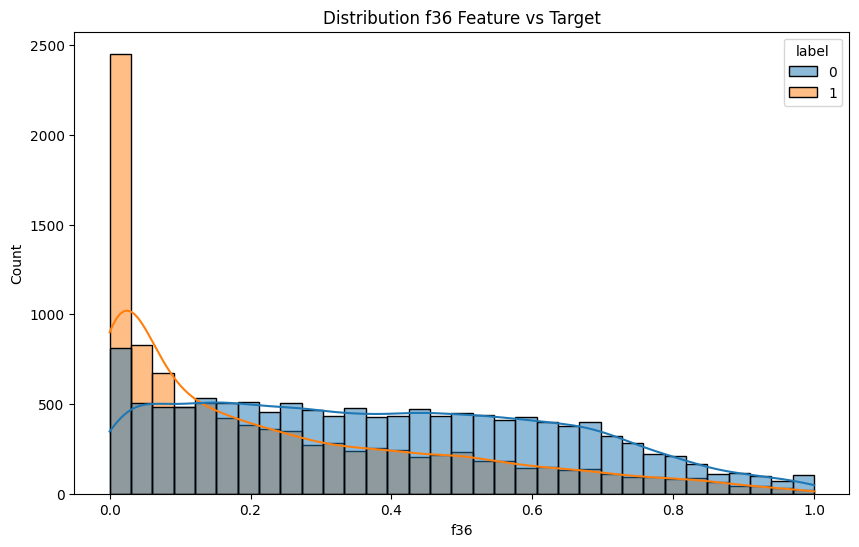

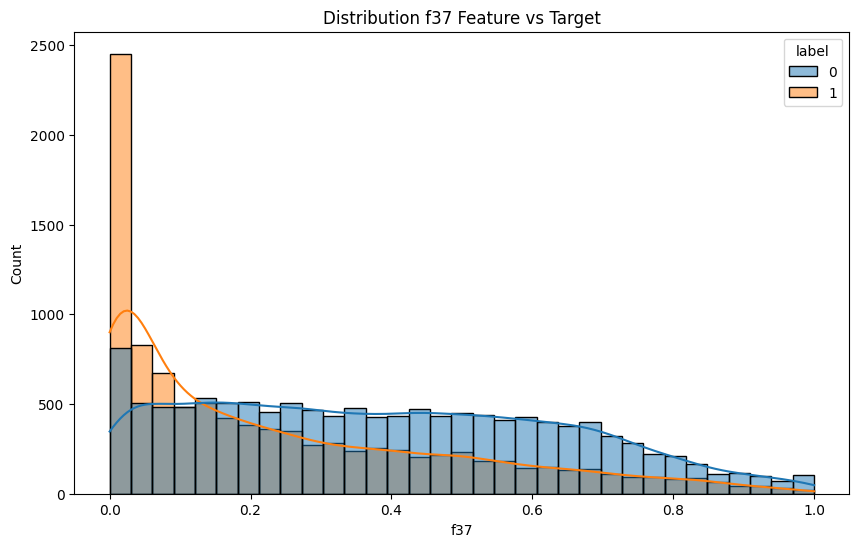

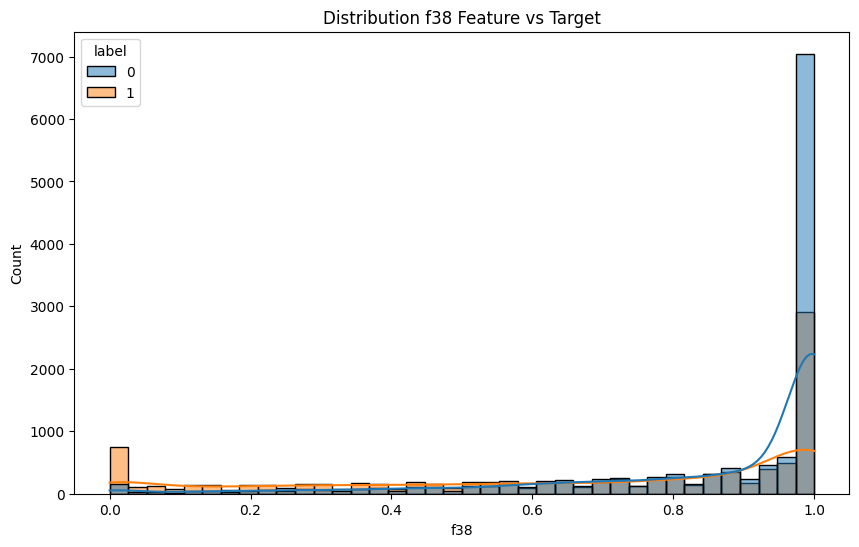

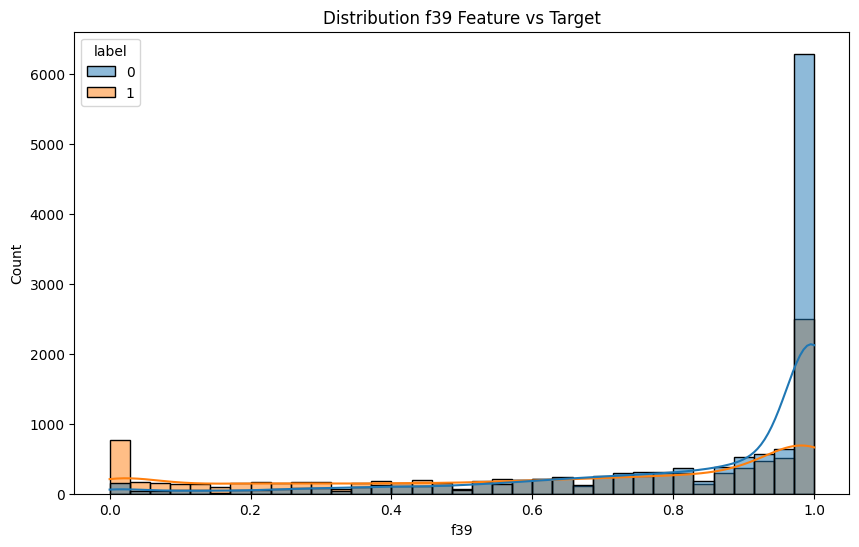

In [17]:
column= num_cols.drop('f40', axis=1)
for col in column:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=waste, x=col, hue=waste['label'], kde=True)
    plt.title(f'Distribution {col} Feature vs Target')
    plt.show()

## 3 . Data Preprocessing 

### 3.1 Handling Data Duplicated

In [18]:
waste = waste.drop_duplicates(keep='first')
print('Number of duplicated data:', waste.duplicated().sum())

Number of duplicated data: 0


### 3.2 Sampling

In [19]:
# Jumlah setengah baris dataset
selisih = waste.shape[0] / 2
print('Setengah baris:', selisih)

Setengah baris: 11262.0


In [20]:
# Get the sample for 1/3
np.random.seed(42)
waste_sample = waste.sample(11262)

In [21]:
waste_sample['label'].value_counts()

label
0    6323
1    4939
Name: count, dtype: int64

<Axes: title={'center': 'Presentase Distribution of Target'}>

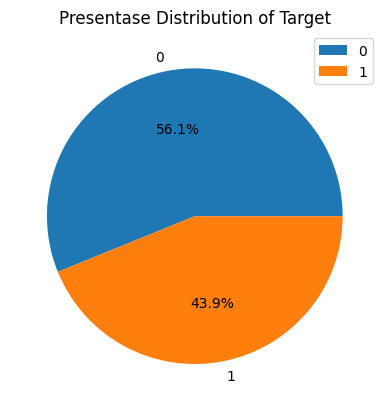

In [22]:
# Presentase penyebaran target
waste_sample['label'].value_counts().plot.pie(autopct='%1.1f%%', title='Presentase Distribution of Target', legend=['Organik', 'Inorganic'])

In [23]:
# Tampilkan selisih presentase target
selisihP = 56.1 - 43.9
print(f'\nSelisih presentase: {selisihP}%')

# Tamplikan selisih data 
selisihD = (selisihP / 100) * waste_sample.shape[0]
print(f'Selisih data:', selisihD)


Selisih presentase: 12.200000000000003%
Selisih data: 1373.9640000000002


### 3.3 Feature Selection 

In [24]:
# Dropping the one of featrue that have a high correlation
cor_col = ['f33', 'f36']
waste_sample = waste_sample.drop(cor_col, axis=1)
print('Number of columns:', waste_sample.shape[1])

Number of columns: 39


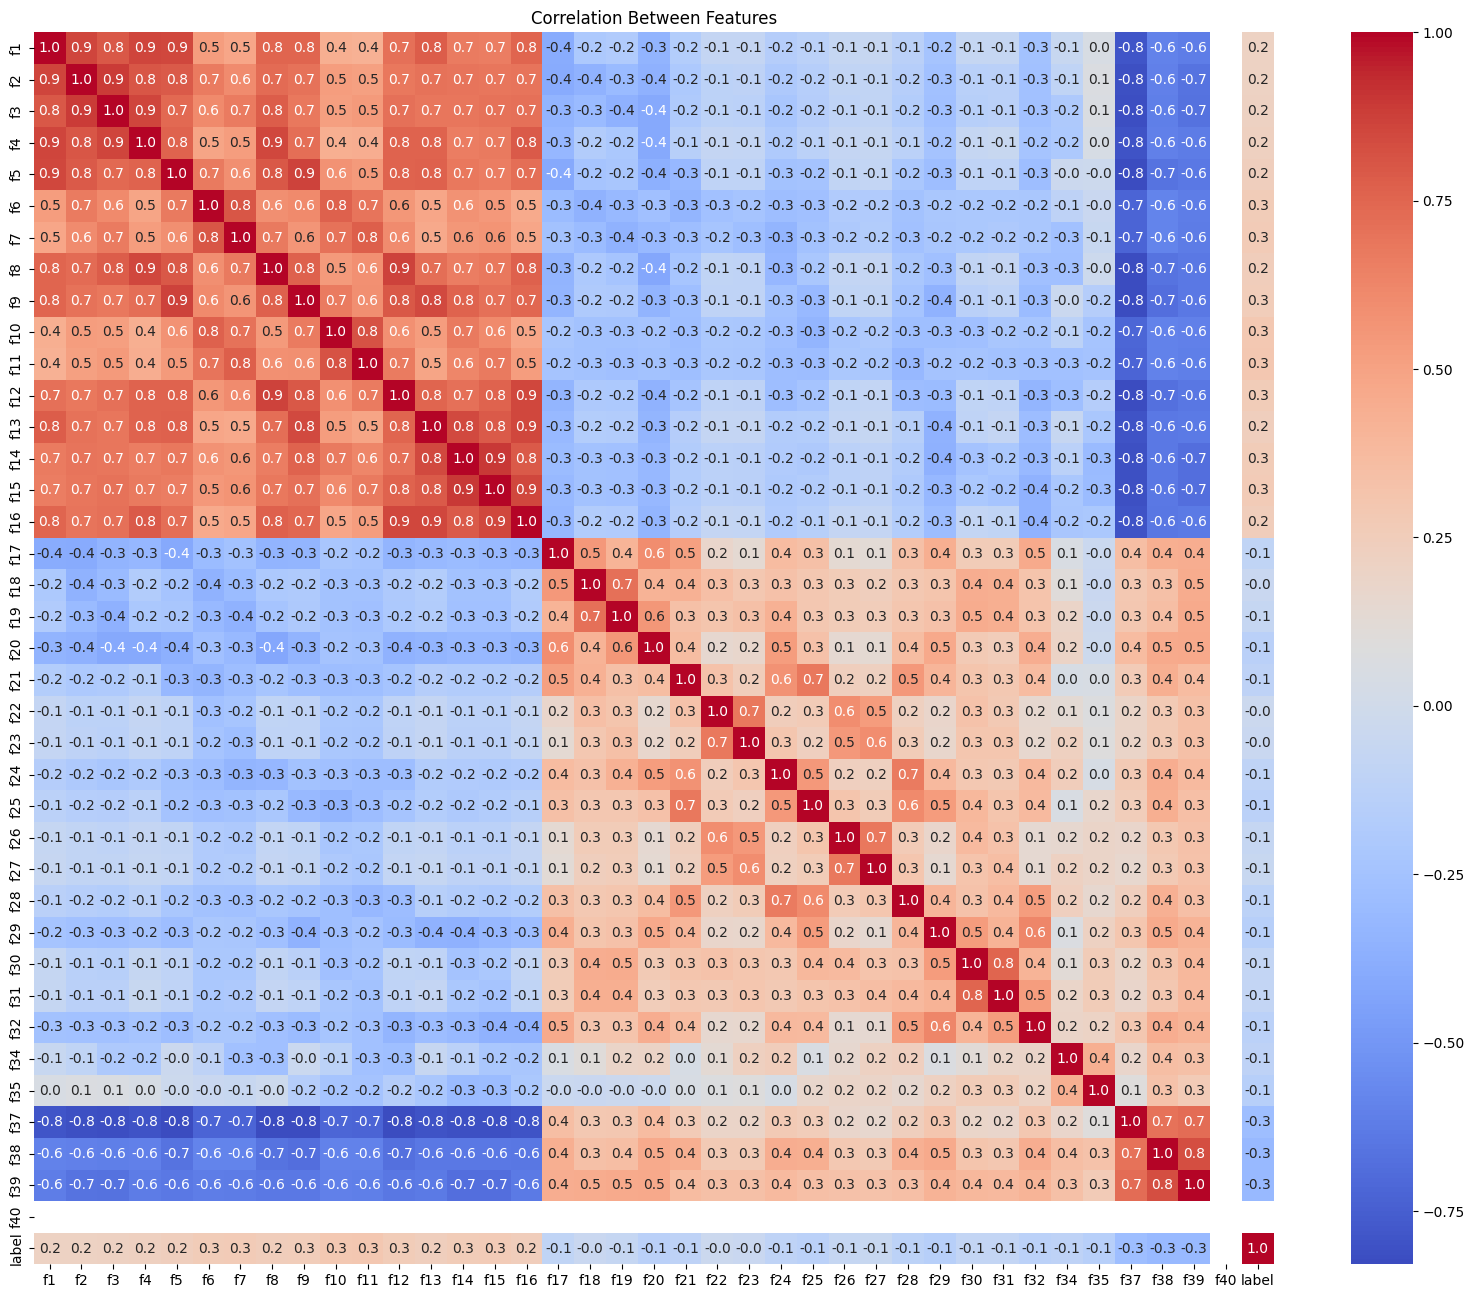

In [25]:
correlation = waste_sample.select_dtypes(include='number').corr()

# Visualization
plt.figure(figsize=(20,16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Between Features')
plt.show()

## 4. Model

### 4.1 Independent & Dependent Variable

In [26]:
# Independent Dependent
X = waste_sample.drop('label', axis=1)
y = waste_sample['label']

### 4.2 Split Data (Stratified Split)

In [27]:
# Stratitifed Split Data

def split_data(X, y, size=0.75):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for classes in np.unique(y):
        class_idx = np.where(y == classes)[0]
        idx = np.random.permutation(len(y))
        split = int(len(class_idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_test = pd.concat(x_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [28]:
# Call the function of split data
X_train, X_test, y_train, y_test = split_data(X, y)

In [29]:
# Show the dimensional data train and test
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(8446, 38)
(14078, 38)
(8446,)
(14078,)


### 4.3 Method KD Tree

In [30]:
class Node:
    def __init__(self, point, label, left=None, right=None, axis=0):
        self.point = np.array(point)
        self.label = label
        self.left = left
        self.right = right
        self.axis = axis

class kdtree:
    def __init__(self, k_dimension):
        self.root = None
        self.k_dimension = k_dimension

    def build(self, point, label, depth=0):
        n = len(point)
        if n == 0:
            return None
        
        axis = depth % self.k_dimension

        sorted_indicies = np.argsort(point[:, axis])
        point = point[sorted_indicies]
        label = label[sorted_indicies]

        median = n // 2

        return Node(
            point = point[median],
            label = label[median],
            left = self.build(point[:median], label[:median], depth + 1),
            right = self.build(point[median+1:], label[median+1:], depth + 1),
            axis = axis 
        )

    def fit(self, X, y):
        self.root = self.build(np.array(X), np.array(y))
        return self

    def _search_nearest(self, node,target, best=None):
        if node is None:
            return best
        
        dist = np.sum((node.point - target) ** 2)

        if best is None or dist < best[0]:
            best = (dist, node.point, node.label)

        diff = target[node.axis] - node.point[point.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        best = self._search_nearest(first, target, best)

        if best[0] > diff ** 2:
            best = self._search_nearest(second, target, best)

        return best

    def nearest_neighbor(self, point):
        result = self._search_nearest(self.root, np.array(point))
        return result[1], result[2]

    def _search_k_nearest(self, node, target, heap, k):
        if node is None:
            return heap

        dist = float(np.sum((node.point - target) ** 2))

        if len(heap) < k:
            heap.append((dist, node.point.copy(), node.label))
        elif dist < heap[0][0]:
            heap[0] = (dist, node.point.copy(), node.label)
            distances = np.array([h[0] for h in heap])
            sorted_indices = np.argsort(distances)[::-1]
            heap = [heap[i] for i in sorted_indices]

        diff = target[node.axis] - node.point[node.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        heap = self._search_k_nearest(first, target, heap, k)

        if len(heap) < k or heap[0][0] > diff ** 2:
            heap = self._search_k_nearest(second, target, heap, k)
        
        return heap

    def k_nearest_neighbors(self, point, k=3):
        point = np.array(point, dtype=float)
        heap = self._search_k_nearest(self.root, np.array(point), [], k)

        distances = np.array([h[0] for h in heap])
        sorted_indices = np.argsort(distances)
        heap = [heap[i] for i in sorted_indices]
        
        return [(p, label) for (_, p, label) in heap]
        

### 4.4 Method KNN

In [31]:
class KNN:
    def __init__(self, n_neighbors=3):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)
        predictions = []
        
        for x in X_test:
            distances = np.sum((self.X_train - x) ** 2, axis=1)
            
            k_indices = np.argpartition(distances, self.k)[:self.k]
            k_labels = self.y_train[k_indices]
          
            unique, counts = np.unique(k_labels, return_counts=True)
            predictions.append(unique[np.argmax(counts)])
            
        return np.array(predictions)

    def score(self, X, y):
        prediction = self.predict(X)
        return np.mean(prediction == y)

### 4.5 Grid Search

In [32]:
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_params = {'k': 0}
    
    for k in [3,5,7,9,11]:

            model = KNN(n_neighbors=k) 
            model.fit(X_train, y_train)
            acc = model.score(X_test.values, y_test)
            
            print(f'K: {k} - Distance: encludian - Accuracy: {acc:.4f}')
            
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k}
                
    print(f'--- FINAL BEST: K={best_params["k"]}, Distance= encludian, Acc={best_acc:.4f} ---')
    return best_params

### 4.5 Resampling 

#### Random Oversampling

In [33]:
def random_sampling(X, y):
    np.random.seed(42)

    counts = y.value_counts()
    max_count = counts.min()
    target_names = counts.index

    X_balanced_list = []
    y_balanced_list = []

    for class_name in target_names:
        X_class = X[y == class_name]
        y_class = y[y == class_name]
        
        # Lakukan resampling agar jumlah tiap kelas sama dengan max_count
        indices = np.random.choice(len(y_class), max_count, replace=True)
        
        X_balanced_list.append(X_class.iloc[indices])
        y_balanced_list.append(y_class.iloc[indices])

    # Gabungkan semua kelas yang sudah seimbang
    X_balanced = pd.concat(X_balanced_list).reset_index(drop=True)
    y_balanced = pd.concat(y_balanced_list).reset_index(drop=True)

    # Shuffle agar urutan kelas acak
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    return X_balanced.iloc[shuffle_idx], y_balanced.iloc[shuffle_idx]

### 4.6 Inisialisasi Fungsi 

#### Random Oversampling

In [34]:
# Resampling

X_train_ros, y_train_ros = random_sampling(X, y)

#### Search K

In [35]:
best_k = search_k(X_train, y_train, X_test)

K: 3 - Distance: encludian - Accuracy: 0.6916
K: 5 - Distance: encludian - Accuracy: 0.6856
K: 7 - Distance: encludian - Accuracy: 0.6892
K: 9 - Distance: encludian - Accuracy: 0.6855
K: 11 - Distance: encludian - Accuracy: 0.6842
--- FINAL BEST: K=3, Distance= encludian, Acc=0.6916 ---


In [36]:
best_k_ros = search_k(X_train_ros, y_train_ros, X_test)


K: 3 - Distance: encludian - Accuracy: 0.7501
K: 5 - Distance: encludian - Accuracy: 0.7191
K: 7 - Distance: encludian - Accuracy: 0.7053
K: 9 - Distance: encludian - Accuracy: 0.6987
K: 11 - Distance: encludian - Accuracy: 0.6987
--- FINAL BEST: K=3, Distance= encludian, Acc=0.7501 ---


In [39]:
model = KNN(n_neighbors=best_k.get('k'))
model.fit(X_train.values, y_train.values)

model_ros = KNN(n_neighbors=best_k_ros.get('k'))
model_ros.fit(X_train_ros.values, y_train_ros.values)

In [40]:
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

y_pred_train_ros = model_ros.predict(X_train_ros.values)
y_pred_test_ros = model_ros.predict(X_test.values)

## 5. Evaluasi 

In [41]:
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    n_classes = len(classes)

    accuracy = np.mean(y_true == y_pred)
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

    precision.append(p)
    recall.append(r)
    f1.append(f)

    print(f'\nEvaluasi Data {title}')
    print(f'Accuracy    : {accuracy}')
    print(f'Precision   : {precision}')
    print(f'Recall      : {recall}')
    print(f'F1          : {f1}')

In [42]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')


Evaluasi Data Train
Accuracy    : 0.8631304759649538
Precision   : [np.float64(0.8595571095571095)]
Recall      : [np.float64(0.8140176600441501)]
F1          : [np.float64(0.8361678004535148)]

Evaluasi Data Test
Accuracy    : 0.6915755078846427
Precision   : [np.float64(0.6707142857142857)]
Recall      : [np.float64(0.6005756315957786)]
F1          : [np.float64(0.6337101400371182)]


In [43]:
evaluate(y_train_ros, y_pred_train_ros)
evaluate(y_test, y_pred_test, title='Test')


Evaluasi Data Train
Accuracy    : 0.8915772423567524
Precision   : [np.float64(0.8942111699959233)]
Recall      : [np.float64(0.888236485118445)]
F1          : [np.float64(0.8912138141188419)]

Evaluasi Data Test
Accuracy    : 0.6915755078846427
Precision   : [np.float64(0.6707142857142857)]
Recall      : [np.float64(0.6005756315957786)]
F1          : [np.float64(0.6337101400371182)]


In [44]:
def confusion_matrix(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == c_true) * (y_pred == c_pred))
            
    plt.figure(figsize=(10,8))
    plt.title(f'Confusion Matrix Data {title}', fontsize=20)
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()
    

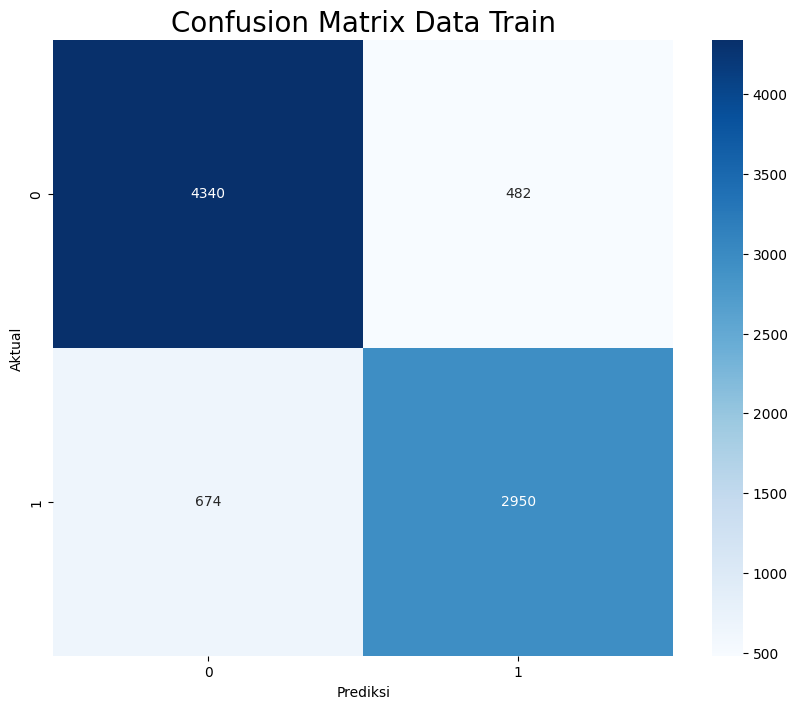

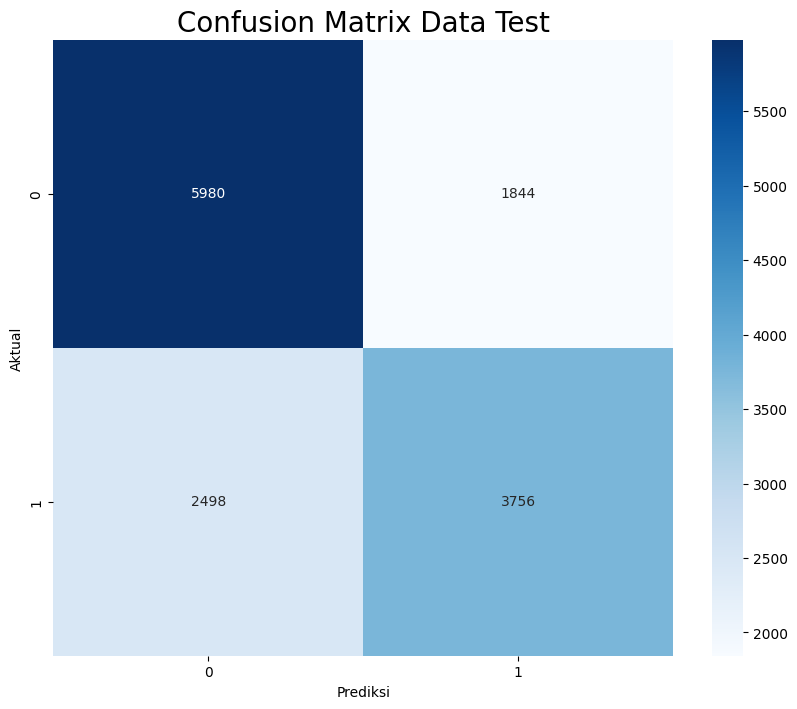

In [45]:
confusion_matrix(y_train, y_pred_train)
confusion_matrix(y_test, y_pred_test, title='Test')

In [46]:
def incorrect_point(y_true, y_pred, X, title='Train'):
    incorrect = y_true != y_pred
    n_incorrect = np.sum(incorrect)

    correct = ~incorrect
    n_correct = np.sum(correct)

    plt.figure(figsize=(10,8))
    plt.title(f'Point Kesalahan Data {title}')
    plt.scatter(X[incorrect, 0], X[incorrect, 1], label=f'Salah {n_incorrect}', color='red')
    plt.scatter(X[correct, 0], X[correct, 1], label=f'Benar {n_correct}', color='blue')
    plt.legend(loc='upper right')
    plt.show()

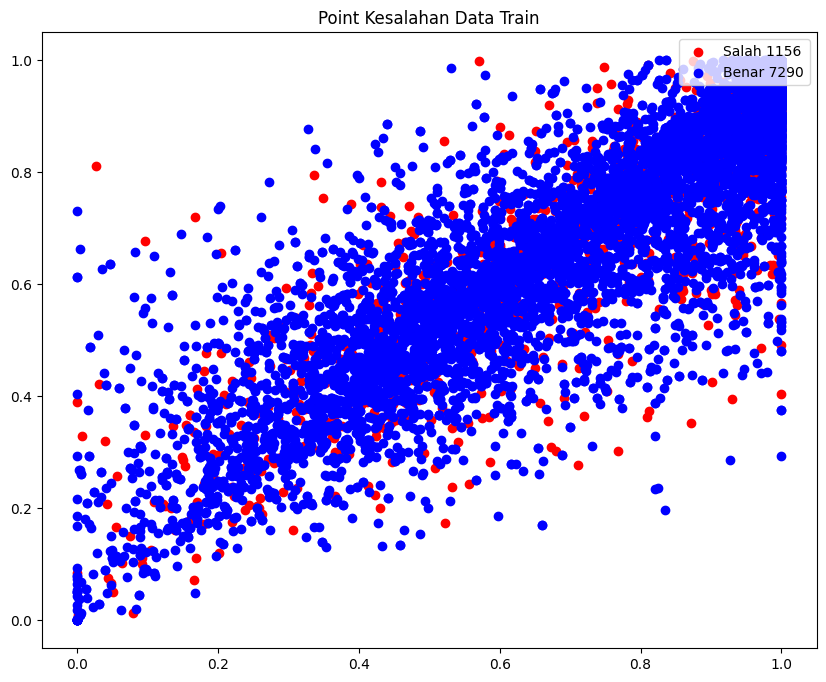

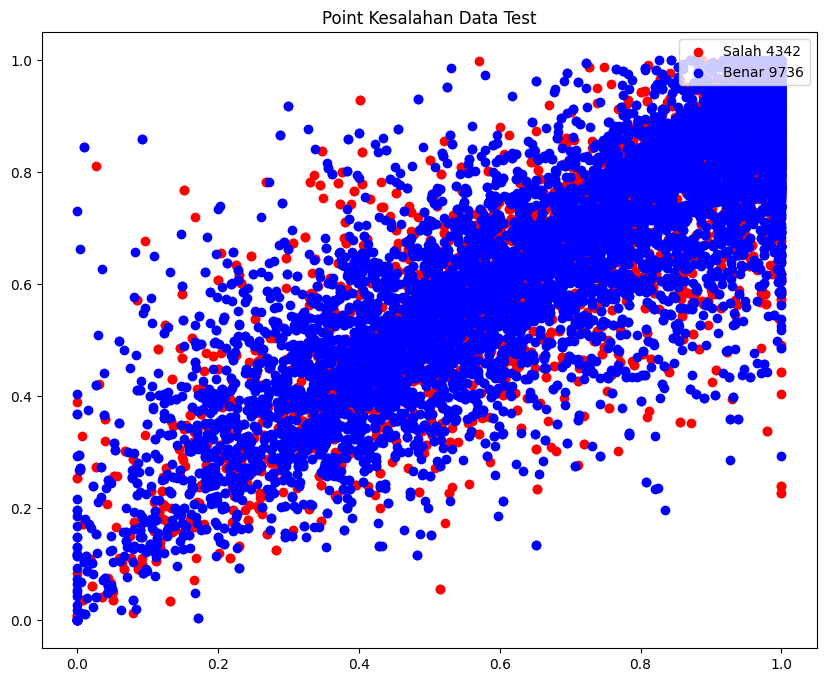

In [47]:
incorrect_point(y_train, y_pred_train, X_train.values)
incorrect_point(y_test, y_pred_test, X_test.values, title='Test')

## 6. Conclution

1. Dataset memiliki data yang cukup bersih. Dimana, dataset tidak memiliki nilai kosong, dan tidak ada nilai yang ekstrem. 
2. Karena ukuran dataset yang cukup besar, kami mengambil sample sebanyak 50% dari dataset untuk mempercepat komputasi. 
